# DATA 266 HW: CycleGAN, Monet

## 0. Personal parameters

In [ ]:
SID4 = 9002  # TODO: last 4 digits of SJSU ID

SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

print(f"SID4={SID4:04d} SEED={SEED} SLICE={SLICE} HP_ID={HP_ID} CLS_A={CLS_A} CLS_B={CLS_B}")
assert SID4 != 0, "set SID4 first"

SID4=9002 SEED=9002 SLICE=2 HP_ID=2 CLS_A=2 CLS_B=3


Only SEED is used in this HW (no HP_ID mapping or class subset is given for it). The others are printed because 0.1 asks for them.

In [ ]:
QUICK = False   # True = smoke test

In [ ]:
%pip install -q torch-fidelity lpips

Note: you may need to restart the kernel to use updated packages.


## 1. Setup

In [ ]:
import os, io, json, math, time, random, copy, glob, zipfile, shutil, platform, datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import linalg

import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

# cudnn.benchmark + some backward kernels using atomics (reflection pad, conv transpose)
# mean runs aren't bit-identical even with the same seed. Trading that for speed.
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")

cuda NVIDIA GeForce RTX 4090


### Find the dataset


In [ ]:
DATA_ROOT = None   # e.g. "/app/content"

IMG_EXT = {".jpg", ".jpeg", ".png"}
SKIP = {"proc", "sys", "dev", "node_modules", "site-packages", "dist-packages", "__pycache__",
        "data266_cyclegan", "checkpoints", "samples", "figures", "human_audit"}

def walk(root, max_depth=6):
    root = Path(root)
    for dirpath, dirnames, filenames in os.walk(root):
        dirnames[:] = [d for d in dirnames if not d.startswith(".") and d not in SKIP]
        if len(Path(dirpath).relative_to(root).parts) >= max_depth:
            dirnames[:] = []
        yield Path(dirpath), dirnames, filenames

def count_imgs(d):
    try:
        return sum(1 for f in os.scandir(d) if f.is_file() and Path(f.name).suffix.lower() in IMG_EXT)
    except OSError:
        return 0

In [ ]:
def find_data(roots):
    for root in roots:
        for d, dirs, _ in walk(root):
            names = {x.lower().strip(): x for x in dirs}
            if "monet_jpg" in names and "photo_jpg" in names:
                m, p = d / names["monet_jpg"], d / names["photo_jpg"]
                if count_imgs(m) and count_imgs(p):
                    return d, m, p
    return None

def unzip_if_needed(roots):
    # in case the kaggle zip was copied over but never extracted
    for root in roots:
        for d, _, files in walk(root, max_depth=3):
            for f in files:
                z = d / f
                if z.suffix.lower() != ".zip" or z.name == "images.zip" or z.with_suffix("").exists():
                    continue
                try:
                    with zipfile.ZipFile(z) as zf:
                        if any("monet_jpg" in n.lower() for n in zf.namelist()):
                            print("extracting", z)
                            zf.extractall(z.with_suffix(""))
                except zipfile.BadZipFile:
                    pass

In [ ]:
cands = [DATA_ROOT, os.getcwd(), os.path.join(os.getcwd(), "content"), "/app", "/content",
         "/workspace", "/kaggle/input", "/data", str(Path.home())]
SEARCH_ROOTS = list(dict.fromkeys(str(Path(r)) for r in cands if r and os.path.isdir(r)))

found = find_data(SEARCH_ROOTS)
if found is None:
    unzip_if_needed(SEARCH_ROOTS)
    found = find_data(SEARCH_ROOTS)

if found is None:
    for r in SEARCH_ROOTS[:4]:
        print(repr(r), sorted(os.listdir(r))[:30])
    raise FileNotFoundError("no folder with monet_jpg/ + photo_jpg/ found, set DATA_ROOT")

DATA_DIR, MONET_DIR, PHOTO_DIR = found
print("data folder:", repr(str(DATA_DIR)))

data folder: '/app/content'


### Output folders + run log
Everything goes next to the data, so it survives a container restart.

In [ ]:
OUT_DIR = DATA_DIR / "data266_cyclegan_v3"   # new folder, earlier results stay untouched
try:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    (OUT_DIR / ".w").write_text("ok")
    (OUT_DIR / ".w").unlink()
except OSError:
    OUT_DIR = Path(os.getcwd()) / "data266_cyclegan"
    print("data folder is read-only, using", OUT_DIR)

FIG_DIR = OUT_DIR / "figures"
CKPT_DIR = OUT_DIR / "checkpoints"
SAMPLE_DIR = OUT_DIR / "samples"
for d in (OUT_DIR, FIG_DIR, CKPT_DIR, SAMPLE_DIR):
    d.mkdir(parents=True, exist_ok=True)
RUN_LOG = OUT_DIR / "RUN_LOG.txt"

In [ ]:
def log(*args):
    ts = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{ts}] " + " ".join(str(a) for a in args)
    print(line, flush=True)
    with open(RUN_LOG, "a") as f:
        f.write(line + "\n")

log("=" * 70)
log(f"new session | SID4={SID4:04d} SEED={SEED} SLICE={SLICE} HP_ID={HP_ID} CLS_A={CLS_A} CLS_B={CLS_B}")
gpu = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else ""
log(f"python {platform.python_version()} | torch {torch.__version__} | device {DEVICE} | {gpu}")
log("data:", DATA_DIR, "| outputs:", OUT_DIR)

[2026-10-01 18:55:52] ======================================================================
[2026-10-01 18:55:52] new session | SID4=9002 SEED=9002 SLICE=2 HP_ID=2 CLS_A=2 CLS_B=3
[2026-10-01 18:55:52] python 3.10.13 | torch 2.1.2 | device cuda | NVIDIA GeForce RTX 4090
[2026-10-01 18:55:52] data: /app/content | outputs: /app/content/data266_cyclegan_v3


### Config

- LSGAN loss, lambda_cyc = 10, lambda_id = 0.5 * 10 = 5 (same as the original repo; identity loss keeps the Monet palette from drifting)
- batch 4, Adam(2e-4, 0.5, 0.999), constant LR for half the run then linear decay to 0
- DiffAugment (color + translation) on every D input, the main fix for D overfitting 300 paintings
- image pool of 50 for D's fakes
- EMA of G weights (decay 0.999), used for eval and the submission
- bf16 autocast, no GradScaler needed (fp16 + scaler is a classic NaN source in GANs)

In [ ]:
CFG = dict(
    data_root=str(DATA_DIR),
    img_size=256,
    load_size=286,        # resize to 286 then random crop 256
    n_eval_photos=1000,   # held-out photos, never trained on

    ngf=64, ndf=64, n_res_blocks=9,
    batch_size=4,
    lr=2e-4,
    betas=(0.5, 0.999),
    lambda_cyc=10.0,
    lambda_id=5.0,
    pool_size=50,
    diffaug="color,translation",
    ema_decay=0.999,
    ema_start=1000,

    epochs=80,           # overwritten per run (screening / final)
    epochs_decay=40,
    n_scales=1,          # discriminator scales, overwritten per run
    steps_per_epoch=800,
    grad_clip=None,       # None = just measure grad norm

    log_every=100,
    sample_every=5,
    eval_every=5,
    ckpt_every=5,
    resume=True,
    use_bf16=DEVICE.type == "cuda",
    channels_last=DEVICE.type == "cuda",
)

In [ ]:
if QUICK:
    CFG.update(epochs=2, epochs_decay=1, steps_per_epoch=20, n_eval_photos=64,
               log_every=5, sample_every=1, eval_every=1, ckpt_every=1, ema_start=5)

with open(OUT_DIR / "config.json", "w") as f:
    json.dump({**CFG, "SID4": SID4, "SEED": SEED, "QUICK": QUICK}, f, indent=2)
log("CFG:", json.dumps(CFG))

[2026-10-01 18:55:54] CFG: {"data_root": "/app/content", "img_size": 256, "load_size": 286, "n_eval_photos": 1000, "ngf": 64, "ndf": 64, "n_res_blocks": 9, "batch_size": 4, "lr": 0.0002, "betas": [0.5, 0.999], "lambda_cyc": 10.0, "lambda_id": 5.0, "pool_size": 50, "diffaug": "color,translation", "ema_decay": 0.999, "ema_start": 1000, "epochs": 80, "epochs_decay": 40, "n_scales": 1, "steps_per_epoch": 800, "grad_clip": null, "log_every": 100, "sample_every": 5, "eval_every": 5, "ckpt_every": 5, "resume": true, "use_bf16": true, "channels_last": true}


## 2. Data

In [ ]:
def list_imgs(d):
    return sorted(p for p in Path(d).iterdir() if p.is_file() and p.suffix.lower() in IMG_EXT)

monet_files = list_imgs(MONET_DIR)
photo_files = list_imgs(PHOTO_DIR)
log(f"monet dir: {MONET_DIR} ({len(monet_files)} files)")
log(f"photo dir: {PHOTO_DIR} ({len(photo_files)} files)")

if not QUICK and (len(monet_files) != 300 or len(photo_files) != 7038):
    log("WARNING: expected 300 monet / 7038 photos, check the copy is complete")

[2026-10-01 18:56:05] monet dir: /app/content/monet_jpg (300 files)
[2026-10-01 18:56:05] photo dir: /app/content/photo_jpg (7038 files)


In [ ]:
# the Kaggle data page also lists .npz files, print what they are if any are here
for p in glob.glob(os.path.join(CFG["data_root"], "**", "*.npz"), recursive=True):
    try:
        with np.load(p) as z:
            log(f"npz: {p} ->", ", ".join(f"{k}{z[k].shape}" for k in z.files))
    except Exception as e:
        log(f"npz: {p} (can't open: {e})")

In [ ]:
def load_uint8(files, size):
    out = np.empty((len(files), size, size, 3), dtype=np.uint8)
    for i, f in enumerate(files):
        im = Image.open(f).convert("RGB")
        if im.size != (size, size):
            im = im.resize((size, size), Image.BICUBIC)
        out[i] = np.asarray(im)
    return torch.from_numpy(out).permute(0, 3, 1, 2).contiguous()  # N,3,H,W uint8

t0 = time.time()
monet_u8 = load_uint8(monet_files, CFG["img_size"])
photo_u8 = load_uint8(photo_files, CFG["img_size"])
log(f"loaded in {time.time()-t0:.1f}s | monet {tuple(monet_u8.shape)} | photo {tuple(photo_u8.shape)}")

[2026-10-01 18:56:48] loaded in 19.6s | monet (300, 3, 256, 256) | photo (7038, 3, 256, 256)


Split:
- 1000 random photos held out for evaluation / checkpoint selection
- the first 300 photos by file name are also kept out of training, because those are exactly the
  photos the course script scores. That way the official score is on photos the model never saw.
- all 300 Monets go into training, there aren't enough to hold any back. Downside: every Monet-side
  metric (ours and the course script's) compares against training paintings (discussed at the end).

In [ ]:
N_OFFICIAL = 300   # the course script scores the first N_EVAL = 300 files by name in each folder
official_idx = set(range(min(N_OFFICIAL, len(photo_files))))   # photo_files is sorted by name

rng = np.random.RandomState(SEED)
perm = rng.permutation(len(photo_files))
eval_idx = np.sort(perm[:CFG["n_eval_photos"]])
train_idx = np.sort([int(i) for i in perm[CFG["n_eval_photos"]:] if int(i) not in official_idx])
if QUICK:
    train_idx = train_idx[:256]
log(f"photos: train {len(train_idx)} | held-out {len(eval_idx)} | official 300 excluded from training")

[2026-10-01 18:56:52] photos: train 5772 | held-out 1000 | official 300 excluded from training


In [ ]:
# sanity checks: no overlap between training photos and anything used for evaluation
assert not set(train_idx.tolist()) & set(eval_idx.tolist())
assert not set(train_idx.tolist()) & official_idx
print("no train/eval overlap, official photos not in training")

no train/eval overlap, official photos not in training


In [ ]:
# whole dataset is ~1.4 GB as uint8, just keep it on the GPU
monet_train = monet_u8.to(DEVICE)
photo_train = photo_u8[train_idx].to(DEVICE)
photo_eval = photo_u8[eval_idx]   # cpu, moved per batch

In [ ]:
def show_grid(imgs, ncol=8, title=None, path=None):
    nrow = math.ceil(len(imgs) / ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(2 * ncol, 2 * nrow))
    axes = np.array(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, im in zip(axes, imgs):
        ax.imshow(im.permute(1, 2, 0).cpu().numpy())
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    if path:
        fig.savefig(path, dpi=110, bbox_inches="tight")
    plt.show()

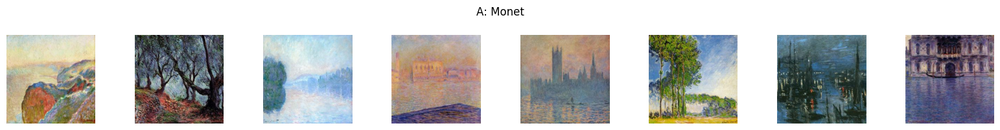

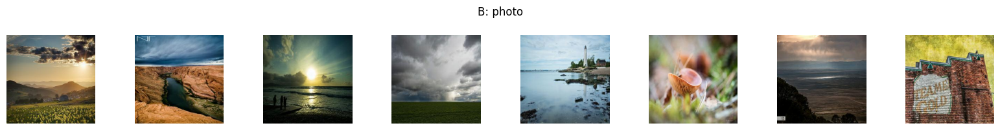

In [ ]:
show_grid(monet_u8[:8], title="A: Monet", path=FIG_DIR / "data_monet.png")
show_grid(photo_u8[:8], title="B: photo", path=FIG_DIR / "data_photo.png")

In [ ]:
def to_float(x_u8):
    return x_u8.float().div_(127.5).sub_(1.0)   # [-1, 1]

def to_u8(x):
    return ((x.float().clamp(-1, 1) + 1) * 127.5).round().to(torch.uint8)

In [ ]:
def sample_batch(pool_u8, bs):
    idx = torch.randint(0, len(pool_u8), (bs,), device=pool_u8.device)
    x = to_float(pool_u8[idx])

    # random flip
    flip = torch.rand(bs, device=x.device) < 0.5
    x = torch.where(flip[:, None, None, None], x.flip(3), x)

    # resize up to 286, random crop back to 256
    L, S = CFG["load_size"], CFG["img_size"]
    x = F.interpolate(x, size=(L, L), mode="bilinear", align_corners=False)
    oy = torch.randint(0, L - S + 1, (bs,))
    ox = torch.randint(0, L - S + 1, (bs,))
    x = torch.stack([x[i, :, oy[i]:oy[i] + S, ox[i]:ox[i] + S] for i in range(bs)])

    if CFG["channels_last"]:
        x = x.contiguous(memory_format=torch.channels_last)
    return x

## 3. Model

Generator from the CycleGAN paper (256px version): c7s1-64, d128, d256, 9 res blocks, u128, u64, c7s1-3, tanh.
Reflection padding + InstanceNorm.

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(ch, ch, 3), nn.InstanceNorm2d(ch), nn.ReLU(True),
            nn.ReflectionPad2d(1), nn.Conv2d(ch, ch, 3), nn.InstanceNorm2d(ch),
        )

    def forward(self, x):
        return x + self.block(x)

In [ ]:
class Generator(nn.Module):
    def __init__(self, ngf=64, n_blocks=9):
        super().__init__()
        layers = [nn.ReflectionPad2d(3), nn.Conv2d(3, ngf, 7), nn.InstanceNorm2d(ngf), nn.ReLU(True)]
        ch = ngf
        for _ in range(2):   # down
            layers += [nn.Conv2d(ch, ch * 2, 3, 2, 1), nn.InstanceNorm2d(ch * 2), nn.ReLU(True)]
            ch *= 2
        layers += [ResBlock(ch) for _ in range(n_blocks)]
        for _ in range(2):   # up
            layers += [nn.ConvTranspose2d(ch, ch // 2, 3, 2, 1, output_padding=1),
                       nn.InstanceNorm2d(ch // 2), nn.ReLU(True)]
            ch //= 2
        layers += [nn.ReflectionPad2d(3), nn.Conv2d(ch, 3, 7), nn.Tanh()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

70x70 PatchGAN: C64 (no norm) - C128 - C256 - C512, outputs a 30x30 grid of scores.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()

        def block(cin, cout, stride, norm=True):
            l = [nn.Conv2d(cin, cout, 4, stride, 1)]
            if norm:
                l.append(nn.InstanceNorm2d(cout))
            l.append(nn.LeakyReLU(0.2, True))
            return l

        self.net = nn.Sequential(
            *block(3, ndf, 2, norm=False),
            *block(ndf, ndf * 2, 2),
            *block(ndf * 2, ndf * 4, 2),
            *block(ndf * 4, ndf * 8, 1),
            nn.Conv2d(ndf * 8, 1, 4, 1, 1),
        )

    def forward(self, x):
        return self.net(x)

Multi-scale option: a second PatchGAN looks at the image downsampled by 2, so it judges larger
structures (layout, colour areas) while the first one judges texture. With `n_scales=1` this is
exactly the single PatchGAN above.

In [ ]:
class MultiScaleD(nn.Module):
    def __init__(self, ndf=64, n_scales=1):
        super().__init__()
        self.ds = nn.ModuleList([Discriminator(ndf) for _ in range(n_scales)])

    def forward(self, x):
        outs = []
        for i, d in enumerate(self.ds):
            if i > 0:
                x = F.avg_pool2d(x, 3, stride=2, padding=1, count_include_pad=False)
            outs.append(d(x))
        return outs   # list, one score map per scale

In [ ]:
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

### DiffAugment
Zhao et al. 2020. Applied to real and fake images going into D. It's differentiable, so G still gets
gradients through it. Cutout is implemented too but left off (policy is color + translation).

In [ ]:
def rand_brightness(x):
    return x + (torch.rand(x.size(0), 1, 1, 1, device=x.device) - 0.5)

def rand_saturation(x):
    m = x.mean(dim=1, keepdim=True)
    return (x - m) * (torch.rand(x.size(0), 1, 1, 1, device=x.device) * 2) + m

def rand_contrast(x):
    m = x.mean(dim=[1, 2, 3], keepdim=True)
    return (x - m) * (torch.rand(x.size(0), 1, 1, 1, device=x.device) + 0.5) + m

In [ ]:
def rand_translation(x, ratio=0.125):
    B, _, H, W = x.shape
    sx, sy = int(H * ratio + 0.5), int(W * ratio + 0.5)
    tx = torch.randint(-sx, sx + 1, (B, 1, 1), device=x.device)
    ty = torch.randint(-sy, sy + 1, (B, 1, 1), device=x.device)
    gb, gx, gy = torch.meshgrid(torch.arange(B, device=x.device), torch.arange(H, device=x.device),
                                torch.arange(W, device=x.device), indexing="ij")
    gx = torch.clamp(gx + tx + 1, 0, H + 1)
    gy = torch.clamp(gy + ty + 1, 0, W + 1)
    xp = F.pad(x, [1, 1, 1, 1])
    return xp.permute(0, 2, 3, 1)[gb, gx, gy].permute(0, 3, 1, 2).contiguous()

def rand_cutout(x, ratio=0.5):
    B, _, H, W = x.shape
    ch, cw = int(H * ratio + 0.5), int(W * ratio + 0.5)
    ox = torch.randint(0, H + (1 - ch % 2), (B, 1, 1), device=x.device)
    oy = torch.randint(0, W + (1 - cw % 2), (B, 1, 1), device=x.device)
    gb, gx, gy = torch.meshgrid(torch.arange(B, device=x.device), torch.arange(ch, device=x.device),
                                torch.arange(cw, device=x.device), indexing="ij")
    gx = torch.clamp(gx + ox - ch // 2, 0, H - 1)
    gy = torch.clamp(gy + oy - cw // 2, 0, W - 1)
    mask = torch.ones(B, H, W, dtype=x.dtype, device=x.device)
    mask[gb, gx, gy] = 0
    return x * mask.unsqueeze(1)

In [ ]:
AUGS = {
    "color": [rand_brightness, rand_saturation, rand_contrast],
    "translation": [rand_translation],
    "cutout": [rand_cutout],
}

def diff_augment(x, policy=CFG["diffaug"]):
    if not policy:
        return x
    for p in policy.split(","):
        for fn in AUGS[p]:
            x = fn(x)
    return x

### Image pool + EMA

In [ ]:
class ImagePool:
    # keeps a history of generated images so D doesn't only see the latest G
    def __init__(self, size):
        self.size = size
        self.items = []

    def query(self, imgs):
        if self.size == 0:
            return imgs
        out = []
        for im in imgs.detach():
            im = im.unsqueeze(0)
            if len(self.items) < self.size:
                self.items.append(im)
                out.append(im)
            elif random.random() < 0.5:
                j = random.randrange(self.size)
                out.append(self.items[j].clone())
                self.items[j] = im
            else:
                out.append(im)
        return torch.cat(out)

In [ ]:
@torch.no_grad()
def ema_update(ema, model, decay):
    for pe, pm in zip(ema.parameters(), model.parameters()):
        pe.lerp_(pm.detach(), 1 - decay)

### Losses + helpers
Models, optimisers and pools are built per training run in section 5.

In [ ]:
mse = nn.MSELoss()
l1 = nn.L1Loss()
AMP = dict(device_type="cuda", dtype=torch.bfloat16, enabled=CFG["use_bf16"])

def ls_loss(preds, target):
    # LSGAN loss, averaged over discriminator scales
    return sum(mse(p.float(), torch.full_like(p, target, dtype=torch.float32)) for p in preds) / len(preds)

def d_mean(preds):
    return preds[0].float().mean().item()   # mean D output at full scale, for logging

In [ ]:
def n_params(m):
    return sum(p.numel() for p in m.parameters())

## 4. Metric helpers

Everything uses 2048-d pool features from the standard FID Inception (`inception-v3-compat` from
torch-fidelity, same weights as the TF reference / Kaggle MiFID), so numbers are comparable.
Features get extracted once per image set and reused for FID, KID, PRDC, MiFID and content cosine.

In [ ]:
from torch_fidelity.feature_extractor_inceptionv3 import FeatureExtractorInceptionV3
INCEPTION = FeatureExtractorInceptionV3("inception-v3-compat", ["2048"]).to(DEVICE).eval()

@torch.no_grad()
def inception_feats(imgs_u8, bs=100):
    out = []
    for i in range(0, len(imgs_u8), bs):
        out.append(INCEPTION(imgs_u8[i:i + bs].to(DEVICE))[0].double().cpu())
    return torch.cat(out).numpy()

In [ ]:
def apply_cal(y255, cal):
    # global per-channel colour correction: (x - mean_gen) / std_gen * std_real + mean_real
    mu_g, sd_g, mu_r, sd_r = (t.to(y255.device).view(1, 3, 1, 1) for t in cal)
    return (y255 - mu_g) / sd_g * sd_r + mu_r

@torch.no_grad()
def translate(G, imgs_u8, cal=None, bs=32):
    G.eval()
    out = []
    for i in range(0, len(imgs_u8), bs):
        x = to_float(imgs_u8[i:i + bs].to(DEVICE))
        if CFG["channels_last"]:
            x = x.contiguous(memory_format=torch.channels_last)
        with torch.autocast(**AMP):
            y = G(x)
        y255 = (y.float().clamp(-1, 1) + 1) * 127.5
        if cal is not None:
            y255 = apply_cal(y255, cal)
        out.append(y255.clamp(0, 255).round().to(torch.uint8).cpu())
    return torch.cat(out)

In [ ]:
def fid(f1, f2):
    mu1, mu2 = f1.mean(0), f2.mean(0)
    s1, s2 = np.cov(f1, rowvar=False), np.cov(f2, rowvar=False)
    covmean = linalg.sqrtm(s1 @ s2)
    if isinstance(covmean, tuple):   # older scipy versions return (sqrtm, err)
        covmean = covmean[0]
    if not np.isfinite(covmean).all():
        eps = np.eye(s1.shape[0]) * 1e-6
        covmean = linalg.sqrtm((s1 + eps) @ (s2 + eps))
    covmean = covmean.real
    return float(((mu1 - mu2) ** 2).sum() + np.trace(s1) + np.trace(s2) - 2 * np.trace(covmean))

In [ ]:
def kid(f1, f2, n_subsets=100, subset_size=None, seed=SEED):
    # unbiased MMD^2, cubic polynomial kernel (Binkowski et al. 2018)
    rs = np.random.RandomState(seed)
    m = subset_size or min(len(f1), len(f2), 1000)
    d = f1.shape[1]
    vals = []
    for _ in range(n_subsets):
        x = f1[rs.choice(len(f1), m, replace=False)]
        y = f2[rs.choice(len(f2), m, replace=False)]
        kxx = (x @ x.T / d + 1) ** 3
        kyy = (y @ y.T / d + 1) ** 3
        kxy = (x @ y.T / d + 1) ** 3
        mmd = ((kxx.sum() - np.trace(kxx)) / (m * (m - 1))
               + (kyy.sum() - np.trace(kyy)) / (m * (m - 1))
               - 2 * kxy.mean())
        vals.append(mmd)
    return float(np.mean(vals)), float(np.std(vals))

In [ ]:
def prdc(real, fake, k=5):
    # precision/recall (Kynkaanniemi 2019), density/coverage (Naeem 2020)
    real = torch.from_numpy(real).float().to(DEVICE)
    fake = torch.from_numpy(fake).float().to(DEVICE)
    d_rr = torch.cdist(real, real)
    d_ff = torch.cdist(fake, fake)
    d_rf = torch.cdist(real, fake)
    r_rad = d_rr.kthvalue(k + 1, dim=1).values   # k+1 skips the self distance
    f_rad = d_ff.kthvalue(k + 1, dim=1).values
    return dict(
        precision=(d_rf < r_rad[:, None]).any(0).float().mean().item(),
        recall=(d_rf < f_rad[None, :]).any(1).float().mean().item(),
        density=((d_rf < r_rad[:, None]).float().sum(0) / k).mean().item(),
        coverage=(d_rf.min(1).values < r_rad).float().mean().item(),
    )

In [ ]:
def mifid(gen, train, fid_value, eps=0.1):
    # Kaggle "I'm Something of a Painter" metric: FID / memorisation distance (if it's below eps)
    g = gen / np.linalg.norm(gen, axis=1, keepdims=True)
    t = train / np.linalg.norm(train, axis=1, keepdims=True)
    d = float((1 - g @ t.T).min(1).mean())
    d_thr = d if d < eps else 1.0
    return fid_value / (d_thr + 1e-15), d

In [ ]:
REAL_MONET_FEATS = inception_feats(monet_u8)
REAL_PHOTO_EVAL_FEATS = inception_feats(photo_eval)
log(f"reference feats: monet {REAL_MONET_FEATS.shape}, held-out photo {REAL_PHOTO_EVAL_FEATS.shape}")

[2026-10-01 18:57:34] reference feats: monet (300, 2048), held-out photo (1000, 2048)


### Official metric (copy of the course evaluation script)
Same network (torchvision Inception-v3, ImageNet weights, fc removed), same preprocessing, same FID
formula, same paired-cosine MiFID, first 300 by name, both directions averaged. Generated images go
through a JPEG round trip first, so in-memory scores match what the script sees from the files.

In [ ]:
import torchvision.models as tvm
import torchvision.transforms as T
from scipy.spatial.distance import cosine as cos_dist

TV_INCEPTION = tvm.inception_v3(weights=tvm.Inception_V3_Weights.IMAGENET1K_V1, transform_input=False)
TV_INCEPTION.fc = nn.Identity()
TV_INCEPTION = TV_INCEPTION.to(DEVICE).eval()

TV_TF = T.Compose([
    T.Resize(299),
    T.CenterCrop(299),
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

In [ ]:
@torch.no_grad()
def tv_feats(pil_images, bs=32):
    feats = []
    for i in range(0, len(pil_images), bs):
        x = torch.stack([TV_TF(im) for im in pil_images[i:i + bs]]).to(DEVICE)
        feats.append(TV_INCEPTION(x).cpu().numpy())
    return np.concatenate(feats)

def pils_from_files(paths):
    return [Image.open(p).convert("RGB") for p in paths]

def pils_via_jpeg(imgs_u8, quality=95):
    # encode + decode, same as saving to disk and reading back
    out = []
    for im in imgs_u8:
        buf = io.BytesIO()
        Image.fromarray(im.permute(1, 2, 0).numpy()).save(buf, format="JPEG", quality=quality)
        buf.seek(0)
        out.append(Image.open(buf).convert("RGB"))
    return out

In [ ]:
def official_fid(real, gen, eps=1e-6):
    mu1, s1 = real.mean(0), np.cov(real, rowvar=False)
    mu2, s2 = gen.mean(0), np.cov(gen, rowvar=False)
    covmean = linalg.sqrtm(s1.dot(s2))
    if isinstance(covmean, tuple):
        covmean = covmean[0]
    if not np.isfinite(covmean).all():
        off = np.eye(s1.shape[0]) * eps
        covmean = linalg.sqrtm((s1 + off).dot(s2 + off))
    covmean = np.real(covmean)
    diff = mu1 - mu2
    return float(diff.dot(diff) + np.trace(s1 + s2 - 2 * covmean))

def official_pair(real, gen):
    # first n of each (n = smaller set), FID + cosine distance paired by index
    n = min(len(real), len(gen))
    real, gen = real[:n], gen[:n]
    mifid_v = float(np.mean([cos_dist(real[i], gen[i]) for i in range(n)]))
    return official_fid(real, gen), mifid_v

In [ ]:
def official_score(real_m, gen_m, real_p, gen_p):
    fid_b2a, mi_b2a = official_pair(real_m, gen_m)   # photo -> Monet
    fid_a2b, mi_a2b = official_pair(real_p, gen_p)   # Monet -> photo
    FID_ = (fid_a2b + fid_b2a) / 2
    MiFID_ = (mi_a2b + mi_b2a) / 2
    return dict(fid_b2a=fid_b2a, mifid_b2a=mi_b2a, fid_a2b=fid_a2b, mifid_a2b=mi_a2b,
                FID=FID_, MiFID=MiFID_, score=(FID_ + MiFID_) / 2)

### Validation set for checkpoint selection
The official script scores the first 300 photos by file name. Choosing checkpoints on exactly those
images would be tuning on the test set, so selection uses held-out photos that are *not* in that
first 300: one batch as inputs for photo→Monet, another as the real-photo reference for Monet→photo.
The Monet side has no alternative: all 300 paintings, sorted by name, same as the script.

In [ ]:
# official_idx (first 300 by name) was defined in the data split
val_pool = [int(i) for i in eval_idx if int(i) not in official_idx]
n_val = min(N_OFFICIAL, len(val_pool) // 2)
VAL_IN_IDX = np.array(val_pool[:n_val])               # photos that get translated to Monet
VAL_REF_IDX = np.array(val_pool[n_val:2 * n_val])     # real photos for the Monet->photo side
log(f"selection set: {len(VAL_IN_IDX)} input photos, {len(VAL_REF_IDX)} reference photos, "
    f"{min(N_OFFICIAL, len(monet_files))} Monets")

[2026-10-01 18:57:42] selection set: 300 input photos, 300 reference photos, 300 Monets


In [ ]:
monet_sorted = monet_u8[:N_OFFICIAL]     # monet_files is sorted, same order as the script
VAL_IN_PHOTOS = photo_u8[VAL_IN_IDX]
VAL_REAL_M = tv_feats(pils_from_files(monet_files[:N_OFFICIAL]))
VAL_REAL_P = tv_feats(pils_from_files([photo_files[i] for i in VAL_REF_IDX]))
log(f"official-metric reference feats: monet {VAL_REAL_M.shape}, photo {VAL_REAL_P.shape}")

[2026-10-01 18:57:46] official-metric reference feats: monet (300, 2048), photo (300, 2048)


In [ ]:
def val_score(gp2m, gm2p, cal=None):
    cal = cal or {}
    gen_m = tv_feats(pils_via_jpeg(translate(gp2m, VAL_IN_PHOTOS, cal.get("P2M"))))
    gen_p = tv_feats(pils_via_jpeg(translate(gm2p, monet_sorted, cal.get("M2P"))))
    return official_score(VAL_REAL_M, gen_m, VAL_REAL_P, gen_p)

## 5. Training

Training is wrapped in a few functions so the same code can run several configurations:
a short **screening** round that compares 4 candidate settings, then one **final** long run with
the winner. Each run has its own folder under `runs/`, its own checkpoints and resumes on its own
if the notebook is interrupted.

Each step: G update (adversarial + λ_cyc·cycle + λ_id·identity, both directions), then D update on
real vs pooled fakes. Every step logs all loss terms, grad norms, mean D outputs and whether anything
went non-finite (those steps are skipped and counted).

In [ ]:
BASE_CFG = dict(CFG)   # every run starts from this and overrides a few keys
RUNS_DIR = OUT_DIR / "runs"
TRAINED_NOW = False    # set to True when a run actually trains in this session

In [ ]:
def build_models():
    global G_P2M, G_M2P, D_M, D_P, EMA_P2M, EMA_M2P, G_params, D_params
    seed_everything(SEED)   # same init for every run, so runs are comparable
    G_P2M = Generator(CFG["ngf"], CFG["n_res_blocks"])
    G_M2P = Generator(CFG["ngf"], CFG["n_res_blocks"])
    D_M = MultiScaleD(CFG["ndf"], CFG["n_scales"])
    D_P = MultiScaleD(CFG["ndf"], CFG["n_scales"])
    for m in (G_P2M, G_M2P, D_M, D_P):
        m.apply(init_weights)
        m.to(DEVICE)
        if CFG["channels_last"]:
            m.to(memory_format=torch.channels_last)
    EMA_P2M = copy.deepcopy(G_P2M).eval().requires_grad_(False)
    EMA_M2P = copy.deepcopy(G_M2P).eval().requires_grad_(False)
    G_params = list(G_P2M.parameters()) + list(G_M2P.parameters())
    D_params = list(D_M.parameters()) + list(D_P.parameters())

In [ ]:
def build_optim():
    global opt_G, opt_D, sched_G, sched_D, pool_M, pool_P, TOTAL_STEPS, DECAY_START
    opt_G = torch.optim.Adam(G_params, lr=CFG["lr"], betas=CFG["betas"])
    opt_D = torch.optim.Adam(D_params, lr=CFG["lr"], betas=CFG["betas"])
    TOTAL_STEPS = CFG["epochs"] * CFG["steps_per_epoch"]
    DECAY_START = (CFG["epochs"] - CFG["epochs_decay"]) * CFG["steps_per_epoch"]
    sched_G = torch.optim.lr_scheduler.LambdaLR(opt_G, lr_factor)
    sched_D = torch.optim.lr_scheduler.LambdaLR(opt_D, lr_factor)
    pool_M = ImagePool(CFG["pool_size"])
    pool_P = ImagePool(CFG["pool_size"])

def lr_factor(step):
    # constant, then linear decay to 0
    if step < DECAY_START:
        return 1.0
    return max(0.0, 1.0 - (step - DECAY_START) / float(TOTAL_STEPS - DECAY_START + 1))

In [ ]:
def save_ckpt(path):
    torch.save(dict(
        G_P2M=G_P2M.state_dict(), G_M2P=G_M2P.state_dict(),
        D_M=D_M.state_dict(), D_P=D_P.state_dict(),
        EMA_P2M=EMA_P2M.state_dict(), EMA_M2P=EMA_M2P.state_dict(),
        opt_G=opt_G.state_dict(), opt_D=opt_D.state_dict(),
        sched_G=sched_G.state_dict(), sched_D=sched_D.state_dict(),
        HIST=HIST, EVAL_HIST=EVAL_HIST, STATE=STATE, CFG=CFG,
    ), path)

def maybe_resume():
    global HIST, EVAL_HIST, STATE
    if not (CFG["resume"] and last_ckpt.exists()):
        return
    ck = torch.load(last_ckpt, map_location=DEVICE, weights_only=False)
    things = dict(G_P2M=G_P2M, G_M2P=G_M2P, D_M=D_M, D_P=D_P, EMA_P2M=EMA_P2M, EMA_M2P=EMA_M2P,
                  opt_G=opt_G, opt_D=opt_D, sched_G=sched_G, sched_D=sched_D)
    for name, obj in things.items():
        obj.load_state_dict(ck[name])
    HIST, EVAL_HIST, STATE = ck["HIST"], ck["EVAL_HIST"], ck["STATE"]
    log(f"run '{RUN_NAME}': resumed at epoch {STATE['epoch']}, step {STATE['step']}")

In [ ]:
def setup_run(name, overrides, epochs, epochs_decay):
    global CFG, RUN_NAME, RUN_DIR, CKPT_DIR, SAMPLE_DIR, last_ckpt, HIST, EVAL_HIST, STATE
    CFG = {**BASE_CFG, **overrides, "epochs": epochs, "epochs_decay": epochs_decay}
    RUN_NAME, RUN_DIR = name, RUNS_DIR / name
    CKPT_DIR, SAMPLE_DIR = RUN_DIR / "checkpoints", RUN_DIR / "samples"
    for d in (CKPT_DIR, SAMPLE_DIR):
        d.mkdir(parents=True, exist_ok=True)
    last_ckpt = CKPT_DIR / "last.pt"
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    build_models()
    build_optim()
    HIST, EVAL_HIST = [], []
    STATE = dict(step=0, epoch=0, nan_steps=0, best_score=float("inf"), train_time=0.0)
    maybe_resume()

In [ ]:
def grad_norm(params):
    params = [p for p in params if p.grad is not None]
    if CFG["grad_clip"]:
        return torch.nn.utils.clip_grad_norm_(params, CFG["grad_clip"]).item()
    return torch.norm(torch.stack([p.grad.detach().float().norm() for p in params])).item()

def set_requires_grad(nets, flag):
    for n in nets:
        for p in n.parameters():
            p.requires_grad_(flag)

In [ ]:
def gen_step(real_P, real_M):
    set_requires_grad([D_M, D_P], False)
    with torch.autocast(**AMP):
        fake_M = G_P2M(real_P)
        rec_P = G_M2P(fake_M)
        fake_P = G_M2P(real_M)
        rec_M = G_P2M(fake_P)
        idt_M = G_P2M(real_M)
        idt_P = G_M2P(real_P)

        adv_P2M = ls_loss(D_M(diff_augment(fake_M)), 1.0)
        adv_M2P = ls_loss(D_P(diff_augment(fake_P)), 1.0)
        cyc_P = l1(rec_P.float(), real_P)
        cyc_M = l1(rec_M.float(), real_M)
        idt_m = l1(idt_M.float(), real_M)
        idt_p = l1(idt_P.float(), real_P)

        loss_G = (adv_P2M + adv_M2P
                  + CFG["lambda_cyc"] * (cyc_P + cyc_M)
                  + CFG["lambda_id"] * (idt_m + idt_p))

    opt_G.zero_grad(set_to_none=True)
    loss_G.backward()
    gn = grad_norm(G_params)
    ok = math.isfinite(loss_G.item()) and math.isfinite(gn)
    if ok:
        opt_G.step()

    stats = dict(G=loss_G.item(), adv_P2M=adv_P2M.item(), adv_M2P=adv_M2P.item(),
                 cyc_P=cyc_P.item(), cyc_M=cyc_M.item(), idt_M=idt_m.item(), idt_P=idt_p.item(), gn_G=gn)
    return fake_M.detach(), fake_P.detach(), stats, ok

In [ ]:
def disc_step(real_P, real_M, fake_M, fake_P):
    set_requires_grad([D_M, D_P], True)
    fake_M = pool_M.query(fake_M)
    fake_P = pool_P.query(fake_P)
    with torch.autocast(**AMP):
        pr_M, pf_M = D_M(diff_augment(real_M)), D_M(diff_augment(fake_M))
        pr_P, pf_P = D_P(diff_augment(real_P)), D_P(diff_augment(fake_P))
        loss_DM = 0.5 * (ls_loss(pr_M, 1.0) + ls_loss(pf_M, 0.0))
        loss_DP = 0.5 * (ls_loss(pr_P, 1.0) + ls_loss(pf_P, 0.0))
        loss_D = loss_DM + loss_DP

    opt_D.zero_grad(set_to_none=True)
    loss_D.backward()
    gn = grad_norm(D_params)
    ok = math.isfinite(loss_D.item()) and math.isfinite(gn)
    if ok:
        opt_D.step()

    stats = dict(D=loss_D.item(), D_M=loss_DM.item(), D_P=loss_DP.item(), gn_D=gn,
                 Dreal_M=d_mean(pr_M), Dfake_M=d_mean(pf_M), Dreal_P=d_mean(pr_P), Dfake_P=d_mean(pf_P))
    return stats, ok

In [ ]:
def after_step():
    sched_G.step()
    sched_D.step()
    STATE["step"] += 1
    if STATE["step"] >= CFG["ema_start"]:
        ema_update(EMA_P2M, G_P2M, CFG["ema_decay"])
        ema_update(EMA_M2P, G_M2P, CFG["ema_decay"])
    else:
        # before ema_start just copy, early weights are junk
        EMA_P2M.load_state_dict(G_P2M.state_dict())
        EMA_M2P.load_state_dict(G_M2P.state_dict())

In [ ]:
# fixed inputs for the per-epoch sample grids
vis_photo = to_float(photo_eval[:4].to(DEVICE))
vis_monet = to_float(monet_u8[:4].to(DEVICE))

@torch.no_grad()
def save_samples(epoch):
    fm = EMA_P2M(vis_photo)
    rp = EMA_M2P(fm)
    fp = EMA_M2P(vis_monet)
    rm = EMA_P2M(fp)
    grid = to_u8(torch.cat([vis_photo, fm, rp, vis_monet, fp, rm])).cpu()

    labels = ["photo", "-> Monet", "-> photo (rec)", "Monet", "-> photo", "-> Monet (rec)"]
    fig, axes = plt.subplots(6, 4, figsize=(8, 12))
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(grid[i].permute(1, 2, 0).numpy())
        ax.set_xticks([])
        ax.set_yticks([])
        if i % 4 == 0:
            ax.set_ylabel(labels[i // 4])
    fig.suptitle(f"{RUN_NAME}, epoch {epoch} (EMA)")
    plt.tight_layout()
    fig.savefig(SAMPLE_DIR / f"epoch_{epoch:03d}.png", dpi=80)
    plt.close(fig)

In [ ]:
def evaluate_and_save(epoch):
    r = val_score(EMA_P2M, EMA_M2P)
    EVAL_HIST.append(dict(epoch=epoch, step=STATE["step"], **r))
    torch.save(dict(EMA_P2M=EMA_P2M.state_dict(), EMA_M2P=EMA_M2P.state_dict(), epoch=epoch, **r),
               CKPT_DIR / f"ema_ep{epoch:03d}.pt")
    log(f"   val (official metric): FID b2a {r['fid_b2a']:.2f} | a2b {r['fid_a2b']:.2f} | "
        f"MiFID {r['MiFID']:.4f} | score {r['score']:.2f}")
    if r["score"] < STATE["best_score"]:
        STATE["best_score"] = r["score"]
        log("   best so far in this run")

In [ ]:
def end_of_epoch(epoch, dt, acc):
    STATE["train_time"] += dt
    STATE["epoch"] = epoch
    n = CFG["steps_per_epoch"]
    log(f"== [{RUN_NAME}] epoch {epoch} | {dt:.1f}s ({n * CFG['batch_size'] / dt:.1f} img/s per domain) | "
        f"G {acc['G']/n:.3f} D {acc['D']/n:.3f} cyc {(acc['cyc_P'] + acc['cyc_M'])/n:.3f} | "
        f"nan steps {STATE['nan_steps']}")
    if epoch == 1 or epoch % 10 == 0:
        log(f"   ETA for this run ~{(CFG['epochs'] - epoch) * dt / 60:.0f} min")
    if epoch % CFG["sample_every"] == 0 or epoch == CFG["epochs"]:
        save_samples(epoch)
    if epoch % CFG["eval_every"] == 0 or epoch == CFG["epochs"]:
        evaluate_and_save(epoch)
    if epoch % CFG["ckpt_every"] == 0 or epoch == CFG["epochs"]:
        save_ckpt(last_ckpt)

In [ ]:
def train_one_epoch(epoch):
    for m in (G_P2M, G_M2P, D_M, D_P):
        m.train()
    bs, acc = CFG["batch_size"], {}
    for _ in range(CFG["steps_per_epoch"]):
        real_P = sample_batch(photo_train, bs)
        real_M = sample_batch(monet_train, bs)
        fake_M, fake_P, g_stats, ok_G = gen_step(real_P, real_M)
        d_stats, ok_D = disc_step(real_P, real_M, fake_M, fake_P)
        if not (ok_G and ok_D):
            STATE["nan_steps"] += 1
            log(f"non-finite at step {STATE['step']}: {g_stats} {d_stats}")
        after_step()
        rec = dict(step=STATE["step"], epoch=epoch, lr=opt_G.param_groups[0]["lr"], **g_stats, **d_stats)
        HIST.append(rec)
        for k, v in rec.items():
            acc[k] = acc.get(k, 0.0) + v
        if STATE["step"] % CFG["log_every"] == 0:
            log(f"[{RUN_NAME}] ep {epoch:3d} step {STATE['step']:6d} | G {rec['G']:.3f} D {rec['D']:.3f} | "
                f"cyc {rec['cyc_P']:.3f}/{rec['cyc_M']:.3f} idt {rec['idt_M']:.3f}/{rec['idt_P']:.3f} | "
                f"gn G {rec['gn_G']:.2f} D {rec['gn_D']:.2f} | lr {rec['lr']:.2e}")
    return acc

In [ ]:
def train_run(name, overrides, epochs, epochs_decay):
    global TRAINED_NOW
    setup_run(name, overrides, epochs, epochs_decay)
    if STATE["epoch"] >= CFG["epochs"]:
        log(f"run '{name}' already complete, loaded from {last_ckpt}")
        TRAINED_NOW = False
        return
    TRAINED_NOW = True
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
    log(f"training run '{name}': {overrides} | {epochs} epochs x {CFG['steps_per_epoch']} steps, batch {CFG['batch_size']}")
    for epoch in range(STATE["epoch"] + 1, CFG["epochs"] + 1):
        t0 = time.time()
        acc = train_one_epoch(epoch)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        end_of_epoch(epoch, time.time() - t0, acc)
    STATE["peak_mem_gb"] = torch.cuda.max_memory_allocated() / 1024**3 if DEVICE.type == "cuda" else float("nan")
    save_ckpt(last_ckpt)
    log(f"run '{name}' done | train time {STATE['train_time']/3600:.2f} h | steps {STATE['step']} | "
        f"nan/inf steps {STATE['nan_steps']} | peak mem {STATE['peak_mem_gb']:.2f} GB")

### 5a. Screening: which settings work best?

Four candidates, each trained briefly (15 epochs: 10 constant LR + 5 decay) from the same seed and
scored on the validation set with the official metric:

| name | λ_cyc | λ_id | D scales | idea |
|---|---|---|---|---|
| `base` | 10 | 5 | 1 | v1/v2 settings |
| `id1` | 10 | 1 | 1 | weaker identity loss → stronger style transfer |
| `ms_id1` | 10 | 1 | 2 | + a second PatchGAN on a half-size image, judges larger-scale layout and colour |
| `ms_cyc5_id1` | 5 | 1 | 2 | + weaker cycle loss, more freedom to change the image |

The winner gets the long run. A candidate only replaces `base` if it's at least 1 point better,
smaller gaps are within the noise of a 300-image score. Takes about 2.5 h on a 4090
(set `RUN_SCREENING = False` to skip it and use `DEFAULT_CONFIG`).

In [ ]:
RUN_SCREENING = True
DEFAULT_CONFIG = "base"
KEEP_SCREEN_CKPTS = False   # screening checkpoints are deleted after scoring to save disk

SCREEN_EPOCHS, SCREEN_DECAY = (1, 1) if QUICK else (15, 5)
FINAL_EPOCHS, FINAL_DECAY = (2, 1) if QUICK else (80, 40)

CANDIDATES = {
    "base":        dict(lambda_cyc=10.0, lambda_id=5.0, n_scales=1),
    "id1":         dict(lambda_cyc=10.0, lambda_id=1.0, n_scales=1),
    "ms_id1":      dict(lambda_cyc=10.0, lambda_id=1.0, n_scales=2),
    "ms_cyc5_id1": dict(lambda_cyc=5.0,  lambda_id=1.0, n_scales=2),
}

In [ ]:
def screen_one(name, overrides):
    res_file = RUNS_DIR / f"screen_{name}" / "result.json"
    if res_file.exists():   # already screened in an earlier session
        return json.load(open(res_file))
    train_run(f"screen_{name}", overrides, SCREEN_EPOCHS, SCREEN_DECAY)
    last = EVAL_HIST[-1]   # end of the short schedule
    row = dict(config=name, **overrides, epoch=last["epoch"], fid_b2a=last["fid_b2a"],
               fid_a2b=last["fid_a2b"], MiFID=last["MiFID"], score=last["score"],
               train_min=STATE["train_time"] / 60)
    json.dump(row, open(res_file, "w"), indent=1)
    if not KEEP_SCREEN_CKPTS:
        shutil.rmtree(CKPT_DIR, ignore_errors=True)
    return row

In [ ]:
screen_rows = [screen_one(n, ov) for n, ov in CANDIDATES.items()] if RUN_SCREENING else []
SCREEN = pd.DataFrame(screen_rows)
if len(SCREEN):
    SCREEN = SCREEN.sort_values("score").reset_index(drop=True)
    SCREEN.to_csv(OUT_DIR / "screening.csv", index=False)
SCREEN.round(3) if len(SCREEN) else "screening skipped"

[2026-10-01 18:58:07] training run 'screen_base': {'lambda_cyc': 10.0, 'lambda_id': 5.0, 'n_scales': 1} | 15 epochs x 800 steps, batch 4
[2026-10-01 18:58:25] [screen_base] ep   1 step    100 | G 10.132 D 0.744 | cyc 0.398/0.230 idt 0.224/0.399 | gn G 22.95 D 25.70 | lr 2.00e-04
[2026-10-01 18:58:41] [screen_base] ep   1 step    200 | G 6.785 D 0.540 | cyc 0.240/0.187 idt 0.173/0.227 | gn G 44.18 D 7.42 | lr 2.00e-04
[2026-10-01 18:58:58] [screen_base] ep   1 step    300 | G 6.834 D 0.449 | cyc 0.229/0.188 idt 0.165/0.214 | gn G 25.16 D 7.55 | lr 2.00e-04
[2026-10-01 18:59:15] [screen_base] ep   1 step    400 | G 6.369 D 0.491 | cyc 0.197/0.197 idt 0.175/0.179 | gn G 38.79 D 9.33 | lr 2.00e-04
[2026-10-01 18:59:32] [screen_base] ep   1 step    500 | G 5.839 D 0.476 | cyc 0.168/0.186 idt 0.167/0.159 | gn G 19.74 D 18.53 | lr 2.00e-04
[2026-10-01 18:59:49] [screen_base] ep   1 step    600 | G 6.899 D 0.465 | cyc 0.215/0.222 idt 0.195/0.169 | gn G 32.68 D 8.46 | lr 2.00e-04
[2026-10-01 19

,config,lambda_cyc,lambda_id,n_scales,epoch,fid_b2a,fid_a2b,MiFID,score,train_min
0,ms_id1,10.0,1.0,2,15,104.525,111.655,0.422,54.256,36.004
1,ms_cyc5_id1,5.0,1.0,2,15,104.220,114.071,0.423,54.785,35.916
2,base,10.0,5.0,1,15,112.131,109.527,0.427,55.628,33.399
3,id1,10.0,1.0,1,15,109.945,113.684,0.426,56.120,33.403


In [ ]:
def pick_config(screen, default="base", margin=1.0):
    if not len(screen):
        return default
    best = screen.iloc[0]
    base_score = screen.set_index("config").score.get(default, float("inf"))
    if best.config != default and base_score - best.score < margin:
        return default   # not clearly better than the baseline, keep the simpler setup
    return best.config

FINAL_CONFIG = pick_config(SCREEN, DEFAULT_CONFIG)
log(f"final config: {FINAL_CONFIG} {CANDIDATES[FINAL_CONFIG]}")

[2026-10-01 21:19:32] final config: ms_id1 {'lambda_cyc': 10.0, 'lambda_id': 1.0, 'n_scales': 2}


### 5b. Final run
The chosen settings, trained for 80 epochs (40 constant + 40 decay), about 3-3.5 h on a 4090.

In [ ]:
train_run("final", CANDIDATES[FINAL_CONFIG], FINAL_EPOCHS, FINAL_DECAY)

[2026-10-01 21:19:32] training run 'final': {'lambda_cyc': 10.0, 'lambda_id': 1.0, 'n_scales': 2} | 80 epochs x 800 steps, batch 4
[2026-10-01 21:19:50] [final] ep   1 step    100 | G 7.907 D 0.751 | cyc 0.413/0.234 idt 0.234/0.422 | gn G 19.28 D 13.40 | lr 2.00e-04
[2026-10-01 21:20:08] [final] ep   1 step    200 | G 6.088 D 0.493 | cyc 0.276/0.222 idt 0.206/0.320 | gn G 30.01 D 6.45 | lr 2.00e-04
[2026-10-01 21:20:26] [final] ep   1 step    300 | G 5.921 D 0.572 | cyc 0.252/0.198 idt 0.189/0.243 | gn G 20.02 D 19.39 | lr 2.00e-04
[2026-10-01 21:20:43] [final] ep   1 step    400 | G 5.908 D 0.448 | cyc 0.219/0.252 idt 0.207/0.223 | gn G 28.62 D 6.96 | lr 2.00e-04
[2026-10-01 21:21:02] [final] ep   1 step    500 | G 5.640 D 0.562 | cyc 0.206/0.247 idt 0.186/0.177 | gn G 27.76 D 12.83 | lr 2.00e-04
[2026-10-01 21:21:20] [final] ep   1 step    600 | G 5.356 D 0.492 | cyc 0.192/0.227 idt 0.197/0.185 | gn G 20.46 D 13.69 | lr 2.00e-04
[2026-10-01 21:21:38] [final] ep   1 step    700 | G 5.

### Training summary
If the final run finished in an earlier session it's just loaded from `last.pt`; its original
training log is then printed back from `RUN_LOG.txt`, so the record always shows the real run.

In [ ]:
import re

def run_log_block(path, name):
    lines = open(path).read().splitlines()
    starts = [i for i, l in enumerate(lines) if f"training run '{name}'" in l]
    for st in reversed(starts):
        for j in range(st, len(lines)):
            if f"run '{name}' done" in lines[j]:
                return lines[st:j + 1]
    return []

if not TRAINED_NOW:
    print(f"(final run trained in an earlier session, original log from {RUN_LOG.name}:)\n")
    print("\n".join(run_log_block(RUN_LOG, "final")))

PEAK_TRAIN_MEM_GB = STATE.get("peak_mem_gb", float("nan"))
PARAMS = {"G_P2M": n_params(G_P2M), "G_M2P": n_params(G_M2P), "D_M": n_params(D_M), "D_P": n_params(D_P)}
PARAMS["total"] = sum(PARAMS.values())
log(f"final run: {STATE['epoch']} epochs | train time {STATE['train_time']/3600:.2f} h | steps {STATE['step']} | "
    f"nan/inf steps {STATE['nan_steps']} | peak train mem {PEAK_TRAIN_MEM_GB:.2f} GB")
log("params:", {k: f"{v/1e6:.3f}M" for k, v in PARAMS.items()})

[2026-10-02 00:50:48] final run: 80 epochs | train time 3.20 h | steps 64000 | nan/inf steps 0 | peak train mem 6.33 GB
[2026-10-02 00:50:48] params: {'G_P2M': '11.378M', 'G_M2P': '11.378M', 'D_M': '5.529M', 'D_P': '5.529M', 'total': '33.815M'}


## 6. Training behaviour

In [ ]:
H = pd.DataFrame(HIST)
E = pd.DataFrame(EVAL_HIST)
H.to_csv(OUT_DIR / "train_history.csv", index=False)
E.to_csv(OUT_DIR / "eval_history.csv", index=False)

win = max(1, CFG["steps_per_epoch"] // 4)
def smooth(s):
    return s.rolling(win, min_periods=1).mean()

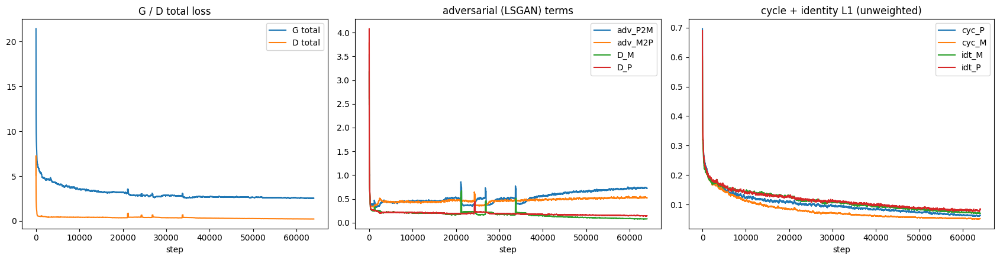

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].plot(H.step, smooth(H.G), label="G total")
ax[0].plot(H.step, smooth(H.D), label="D total")
ax[0].set_title("G / D total loss")
for c in ["adv_P2M", "adv_M2P", "D_M", "D_P"]:
    ax[1].plot(H.step, smooth(H[c]), label=c)
ax[1].set_title("adversarial (LSGAN) terms")
for c in ["cyc_P", "cyc_M", "idt_M", "idt_P"]:
    ax[2].plot(H.step, smooth(H[c]), label=c)
ax[2].set_title("cycle + identity L1 (unweighted)")
for a in ax:
    a.set_xlabel("step")
    a.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "loss_curves.png", dpi=120)
plt.show()

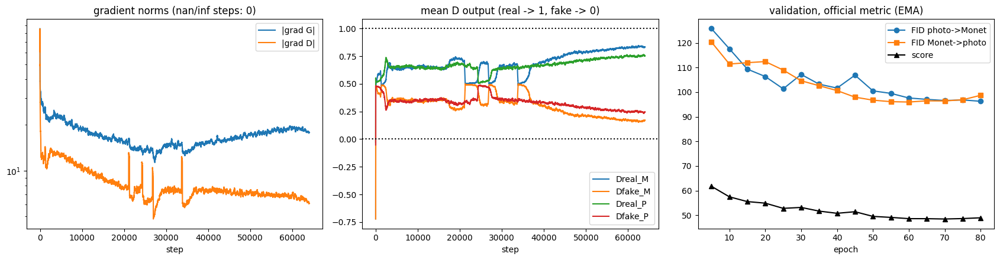

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].plot(H.step, smooth(H.gn_G), label="|grad G|")
ax[0].plot(H.step, smooth(H.gn_D), label="|grad D|")
ax[0].set_yscale("log")
ax[0].set_title(f"gradient norms (nan/inf steps: {STATE['nan_steps']})")
for c in ["Dreal_M", "Dfake_M", "Dreal_P", "Dfake_P"]:
    ax[1].plot(H.step, smooth(H[c]), label=c)
ax[1].axhline(1, ls=":", c="k")
ax[1].axhline(0, ls=":", c="k")
ax[1].set_title("mean D output (real -> 1, fake -> 0)")
if len(E):
    ax[2].plot(E.epoch, E.fid_b2a, "o-", label="FID photo->Monet")
    ax[2].plot(E.epoch, E.fid_a2b, "s-", label="FID Monet->photo")
    ax[2].plot(E.epoch, E.score, "k^-", label="score")
ax[2].set_title("validation, official metric (EMA)")
ax[2].set_xlabel("epoch")
ax[0].set_xlabel("step")
ax[1].set_xlabel("step")
for a in ax:
    a.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "stability_curves.png", dpi=120)
plt.show()

In [ ]:
q = len(H) // 4
stab = dict(
    nan_inf_steps=STATE["nan_steps"],
    gnG_median=H.gn_G.median(), gnG_p99=H.gn_G.quantile(.99), gnG_max=H.gn_G.max(),
    gnD_median=H.gn_D.median(), gnD_p99=H.gn_D.quantile(.99), gnD_max=H.gn_D.max(),
    cyc_first_quarter=(H.cyc_P + H.cyc_M)[:q].mean(),
    cyc_last_quarter=(H.cyc_P + H.cyc_M)[-q:].mean(),
    idt_last_quarter=(H.idt_M + H.idt_P)[-q:].mean(),
    D_last_quarter=H.D[-q:].mean(),
    G_adv_last_quarter=(H.adv_P2M + H.adv_M2P)[-q:].mean(),
    G_std_last_quarter=H.G[-q:].std(),
    D_std_last_quarter=H.D[-q:].std(),
)
log("stability:", json.dumps({k: round(float(v), 4) for k, v in stab.items()}))
pd.Series(stab).round(4)

[2026-10-02 00:50:53] stability: {"nan_inf_steps": 0.0, "gnG_median": 16.2977, "gnG_p99": 33.7159, "gnG_max": 146.8184, "gnD_median": 7.3348, "gnD_p99": 18.7999, "gnD_max": 434.9176, "cyc_first_quarter": 0.2796, "cyc_last_quarter": 0.1218, "idt_last_quarter": 0.161, "D_last_quarter": 0.245, "G_adv_last_quarter": 1.2139, "G_std_last_quarter": 0.2269, "D_std_last_quarter": 0.0424}


nan_inf_steps           0.0000
gnG_median             16.2977
gnG_p99                33.7159
gnG_max               146.8184
gnD_median              7.3348
gnD_p99                18.7999
gnD_max               434.9176
cyc_first_quarter       0.2796
cyc_last_quarter        0.1218
idt_last_quarter        0.1610
D_last_quarter          0.2450
G_adv_last_quarter      1.2139
G_std_last_quarter      0.2269
D_std_last_quarter      0.0424
dtype: float64

## 7. Checkpoint selection
Every saved EMA checkpoint of the final run was scored on the validation set during training. On top of that, try
averaging the weights of the best 3 and keep whichever scores lowest. With 300 images per side the
score moves by roughly 1-2 points between near-identical models, so tiny differences are noise.

In [ ]:
E = pd.DataFrame(EVAL_HIST).sort_values("score").reset_index(drop=True)
E[["epoch", "fid_b2a", "fid_a2b", "FID", "MiFID", "score"]].round(3).head(10)

,epoch,fid_b2a,fid_a2b,FID,MiFID,score
0,70,96.597,96.420,96.509,0.415,48.462
1,65,97.067,96.465,96.766,0.415,48.591
2,60,97.619,95.980,96.799,0.415,48.607
3,75,96.827,96.896,96.862,0.414,48.638
4,80,96.282,98.713,97.497,0.415,48.956
5,55,99.493,96.126,97.809,0.416,49.113
6,50,100.511,96.740,98.626,0.416,49.521
7,40,101.648,100.631,101.140,0.418,50.779
8,45,106.889,97.956,102.422,0.417,51.419
9,35,103.229,102.607,102.918,0.420,51.669


In [ ]:
def load_ema(path):
    return torch.load(path, map_location=DEVICE, weights_only=False)

def average_states(states):
    return {k: sum(st[k].float() for st in states) / len(states) for k in states[0]}

In [ ]:
TOP_K = 3
top_epochs = E.epoch.head(TOP_K).astype(int).tolist()
top = [load_ema(CKPT_DIR / f"ema_ep{e:03d}.pt") for e in top_epochs]
avg_P2M = average_states([t["EMA_P2M"] for t in top])
avg_M2P = average_states([t["EMA_M2P"] for t in top])
log("best epochs on validation:", top_epochs)

[2026-10-02 00:50:57] best epochs on validation: [70, 65, 60]


In [ ]:
EMA_P2M.load_state_dict(avg_P2M)
EMA_M2P.load_state_dict(avg_M2P)
r_avg = val_score(EMA_P2M, EMA_M2P)
log(f"average of top-{len(top)}: score {r_avg['score']:.3f} | best single (epoch {top_epochs[0]}): {E.score.iloc[0]:.3f}")

[2026-10-02 00:51:06] average of top-3: score 48.285 | best single (epoch 70): 48.462


In [ ]:
if len(top) >= 2 and r_avg["score"] < E.score.iloc[0]:
    winner = dict(EMA_P2M=avg_P2M, EMA_M2P=avg_M2P, epoch=f"avg of epochs {top_epochs}", **r_avg)
else:
    winner = top[0]
torch.save(winner, CKPT_DIR / "best_ema.pt")
log(f"selected: {winner['epoch']} | validation score {winner['score']:.3f}")

[2026-10-02 00:51:07] selected: avg of epochs [70, 65, 60] | validation score 48.285


## 8. Colour calibration (optional post-processing)

A global per-channel colour correction of the generator output: shift/scale each RGB channel so its
mean and std match the target domain. Statistics come from **training data only** (training photos
and the Monets) and the model's outputs on training photos; that's 6 numbers per direction, the
same correction for every image. It's applied per direction only if it improves the validation
score, and it's reported in METRICS.md.

In [ ]:
best_sel = load_ema(CKPT_DIR / "best_ema.pt")
EMA_P2M.load_state_dict(best_sel["EMA_P2M"])
EMA_M2P.load_state_dict(best_sel["EMA_M2P"])

def channel_stats(imgs_u8):
    x = imgs_u8.float()
    return x.mean(dim=(0, 2, 3)), x.std(dim=(0, 2, 3))

In [ ]:
rs_cal = np.random.RandomState(SEED + 7)
cal_idx = np.sort(rs_cal.choice(train_idx, min(500, len(train_idx)), replace=False))
cal_photos = photo_u8[cal_idx]                      # training photos only
gen_m = translate(EMA_P2M, cal_photos)
gen_p = translate(EMA_M2P, monet_u8)
CAL_FIT = {"P2M": (*channel_stats(gen_m), *channel_stats(monet_u8)),
           "M2P": (*channel_stats(gen_p), *channel_stats(cal_photos))}
del gen_m, gen_p

In [ ]:
r_raw = val_score(EMA_P2M, EMA_M2P)
r_cal = val_score(EMA_P2M, EMA_M2P, cal=CAL_FIT)
CAL = {}
if r_cal["fid_b2a"] + r_cal["mifid_b2a"] < r_raw["fid_b2a"] + r_raw["mifid_b2a"]:
    CAL["P2M"] = CAL_FIT["P2M"]
if r_cal["fid_a2b"] + r_cal["mifid_a2b"] < r_raw["fid_a2b"] + r_raw["mifid_a2b"]:
    CAL["M2P"] = CAL_FIT["M2P"]
r_final = val_score(EMA_P2M, EMA_M2P, cal=CAL)
torch.save(CAL, CKPT_DIR / "color_cal.pt")

In [ ]:
log(f"validation without calibration: b2a {r_raw['fid_b2a']:.2f} a2b {r_raw['fid_a2b']:.2f} score {r_raw['score']:.3f}")
log(f"validation with calibration:    b2a {r_cal['fid_b2a']:.2f} a2b {r_cal['fid_a2b']:.2f} score {r_cal['score']:.3f}")
log(f"calibration used for: {sorted(CAL) or 'nothing'} -> validation score {r_final['score']:.3f}")

[2026-10-02 00:51:37] validation without calibration: b2a 96.74 a2b 95.57 score 48.285
[2026-10-02 00:51:37] validation with calibration:    b2a 97.88 a2b 94.98 score 48.422
[2026-10-02 00:51:37] calibration used for: ['M2P'] -> validation score 48.137


In [ ]:
def to_monet(imgs_u8):
    return translate(EMA_P2M, imgs_u8, CAL.get("P2M"))

def to_photo(imgs_u8):
    return translate(EMA_M2P, imgs_u8, CAL.get("M2P"))

## 9. Final evaluation
Using the checkpoint chosen above (lowest official-metric score on the validation set).

In [ ]:
best = torch.load(CKPT_DIR / "best_ema.pt", map_location=DEVICE, weights_only=False)
EMA_P2M.load_state_dict(best["EMA_P2M"])
EMA_M2P.load_state_dict(best["EMA_M2P"])
log(f"selected checkpoint: {best['epoch']} (validation score {best['score']:.3f})")

[2026-10-02 00:51:37] selected checkpoint: avg of epochs [70, 65, 60] (validation score 48.285)


In [ ]:
fake_monet = to_monet(photo_eval)    # held-out photo -> Monet
fake_photo = to_photo(monet_u8)      # Monet -> photo
rec_photo = to_photo(fake_monet)     # photo -> Monet -> photo
rec_monet = to_monet(fake_photo)     # Monet -> photo -> Monet

F_fake_M = inception_feats(fake_monet)
F_fake_P = inception_feats(fake_photo)
F_in_P, F_in_M = REAL_PHOTO_EVAL_FEATS, REAL_MONET_FEATS

In [ ]:
M = {}
M["FID_photo2monet"] = fid(F_fake_M, F_in_M)
M["FID_monet2photo"] = fid(F_fake_P, F_in_P)

kid_ss = min(100, len(F_in_M), len(F_in_P))   # only 300 monets -> subsets of 100
M["KID_photo2monet"], M["KID_photo2monet_std"] = kid(F_fake_M, F_in_M, subset_size=kid_ss)
M["KID_monet2photo"], M["KID_monet2photo_std"] = kid(F_fake_P, F_in_P, subset_size=kid_ss)

# floor: FID between two halves of real held-out photos, i.e. how much is just sample noise
h = len(F_in_P) // 2
M["FID_floor_photo_vs_photo"] = fid(F_in_P[:h], F_in_P[h:])
{k: round(v, 3) for k, v in M.items()}

{'FID_photo2monet': 93.219,
 'FID_monet2photo': 85.949,
 'KID_photo2monet': 0.021,
 'KID_photo2monet_std': 0.002,
 'KID_monet2photo': 0.02,
 'KID_monet2photo_std': 0.002,
 'FID_floor_photo_vs_photo': 57.321}

In [ ]:
for k, v in prdc(F_in_M, F_fake_M).items():
    M[f"{k}_photo2monet"] = v
for k, v in prdc(F_in_P, F_fake_P).items():
    M[f"{k}_monet2photo"] = v

M["MiFID_photo2monet"], M["memorization_dist"] = mifid(F_fake_M, F_in_M, M["FID_photo2monet"])
{k: round(v, 4) for k, v in M.items() if "precision" in k or "recall" in k or "density" in k
 or "coverage" in k or "MiFID" in k or "memor" in k}

{'precision_photo2monet': 0.483,
 'recall_photo2monet': 0.59,
 'density_photo2monet': 0.4076,
 'coverage_photo2monet': 0.8367,
 'precision_monet2photo': 0.7133,
 'recall_monet2photo': 0.436,
 'density_monet2photo': 0.7187,
 'coverage_monet2photo': 0.451,
 'MiFID_photo2monet': 93.2187,
 'memorization_dist': 0.2548}

In [ ]:
def cos_rows(a, b):
    a = a / np.linalg.norm(a, axis=1, keepdims=True)
    b = b / np.linalg.norm(b, axis=1, keepdims=True)
    return (a * b).sum(1)

cos_p2m = cos_rows(F_in_P, F_fake_M)
cos_m2p = cos_rows(F_in_M, F_fake_P)
M["content_cos_photo2monet"] = float(cos_p2m.mean())
M["content_cos_monet2photo"] = float(cos_m2p.mean())
# unrelated pairs, to give the number some scale
M["content_cos_unrelated_baseline"] = float(cos_rows(F_in_P, np.roll(F_in_P, 1, axis=0)).mean())

In [ ]:
def l1_px(a, b):
    return (a.float() - b.float()).abs().mean(dim=(1, 2, 3)) / 127.5   # same scale as the training loss

cycL1_P = l1_px(rec_photo, photo_eval)
cycL1_M = l1_px(rec_monet, monet_u8)
M["cycle_L1_photo"] = float(cycL1_P.mean())
M["cycle_L1_monet"] = float(cycL1_M.mean())
M["cycle_L1_unrelated_baseline"] = float(l1_px(photo_eval, photo_eval.roll(1, 0)).mean())

LPIPS (AlexNet, lower = more similar). input vs translation = how much the translation changes,
input vs reconstruction = perceptual version of the cycle loss.

In [ ]:
import lpips
LPIPS = lpips.LPIPS(net="alex", verbose=False).to(DEVICE).eval()

@torch.no_grad()
def lpips_pairs(a_u8, b_u8, bs=50):
    out = []
    for i in range(0, len(a_u8), bs):
        a = to_float(a_u8[i:i + bs].to(DEVICE))
        b = to_float(b_u8[i:i + bs].to(DEVICE))
        out.append(LPIPS(a, b).flatten().cpu())
    return torch.cat(out).numpy()

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
lp_p2m = lpips_pairs(photo_eval, fake_monet)
lp_m2p = lpips_pairs(monet_u8, fake_photo)
lp_recP = lpips_pairs(photo_eval, rec_photo)
lp_recM = lpips_pairs(monet_u8, rec_monet)

M["LPIPS_input_vs_translation_photo2monet"] = float(lp_p2m.mean())
M["LPIPS_input_vs_translation_monet2photo"] = float(lp_m2p.mean())
M["LPIPS_input_vs_reconstruction_photo"] = float(lp_recP.mean())
M["LPIPS_input_vs_reconstruction_monet"] = float(lp_recM.mean())
M["LPIPS_unrelated_baseline"] = float(lpips_pairs(photo_eval[:500], photo_eval.roll(1, 0)[:500]).mean())

In [ ]:
log("final metrics:\n" + json.dumps({k: round(v, 5) for k, v in M.items()}, indent=1))
pd.Series(M).round(5).to_frame("value")

[2026-10-02 00:58:11] final metrics:
{
 "FID_photo2monet": 93.21869,
 "FID_monet2photo": 85.94945,
 "KID_photo2monet": 0.02063,
 "KID_photo2monet_std": 0.00206,
 "KID_monet2photo": 0.01951,
 "KID_monet2photo_std": 0.0022,
 "FID_floor_photo_vs_photo": 57.3212,
 "precision_photo2monet": 0.483,
 "recall_photo2monet": 0.59,
 "density_photo2monet": 0.4076,
 "coverage_photo2monet": 0.83667,
 "precision_monet2photo": 0.71333,
 "recall_monet2photo": 0.436,
 "density_monet2photo": 0.71867,
 "coverage_monet2photo": 0.451,
 "MiFID_photo2monet": 93.21869,
 "memorization_dist": 0.25478,
 "content_cos_photo2monet": 0.7343,
 "content_cos_monet2photo": 0.78487,
 "content_cos_unrelated_baseline": 0.56891,
 "cycle_L1_photo": 0.11675,
 "cycle_L1_monet": 0.07295,
 "cycle_L1_unrelated_baseline": 0.57423,
 "LPIPS_input_vs_translation_photo2monet": 0.38907,
 "LPIPS_input_vs_translation_monet2photo": 0.34756,
 "LPIPS_input_vs_reconstruction_photo": 0.20967,
 "LPIPS_input_vs_reconstruction_monet": 0.28707,
 "L

,value
FID_photo2monet,93.21869
FID_monet2photo,85.94945
KID_photo2monet,0.02063
KID_photo2monet_std,0.00206
KID_monet2photo,0.01951
KID_monet2photo_std,0.00220
FID_floor_photo_vs_photo,57.32120
precision_photo2monet,0.48300
recall_photo2monet,0.59000
density_photo2monet,0.40760


## 10. Qualitative results

In [ ]:
def triptych(inp, out, rec, labels, path, n=8, seed=SEED):
    idx = np.random.RandomState(seed).choice(len(inp), n, replace=False)
    fig, axes = plt.subplots(3, n, figsize=(2.2 * n, 7))
    for j, i in enumerate(idx):
        for r, src in enumerate((inp, out, rec)):
            axes[r, j].imshow(src[i].permute(1, 2, 0).numpy())
            axes[r, j].set_xticks([])
            axes[r, j].set_yticks([])
    for r, lab in enumerate(labels):
        axes[r, 0].set_ylabel(lab, fontsize=11)
    plt.tight_layout()
    fig.savefig(path, dpi=110)
    plt.show()

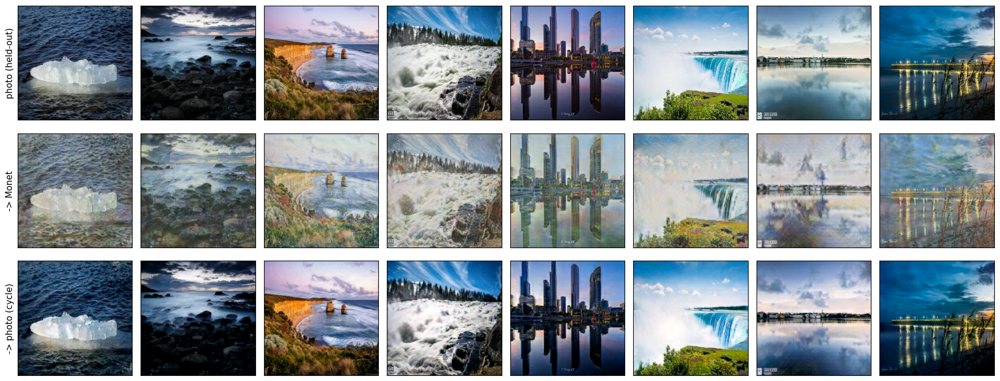

In [ ]:
triptych(photo_eval, fake_monet, rec_photo, ["photo (held-out)", "-> Monet", "-> photo (cycle)"],
         FIG_DIR / "qual_photo2monet.png")

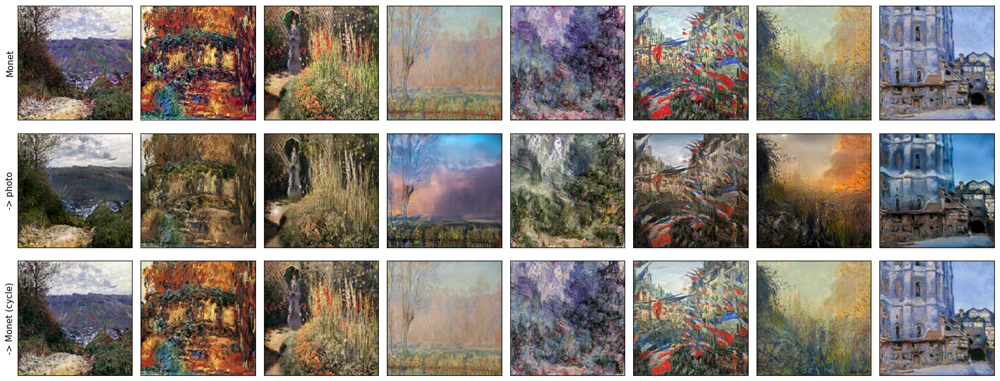

In [ ]:
triptych(monet_u8, fake_photo, rec_monet, ["Monet", "-> photo", "-> Monet (cycle)"],
         FIG_DIR / "qual_monet2photo.png")

## 11. Checking the cycle-consistency implementation

1. G keeps the shape and outputs stay in [-1, 1]
2. the cycle loss actually backprops into *both* generators (so F(G(x)) really is composed), and an identity loss on one G doesn't touch the other
3. reconstruction error is way below the unrelated-image baseline, and below input-vs-translation
4. cycle loss went down during training

In [ ]:
checks = {}
x = to_float(photo_eval[:2].to(DEVICE))
with torch.no_grad():
    y = G_P2M(x)
checks["shape_preserved"] = tuple(y.shape) == tuple(x.shape)
checks["output_in_[-1,1]"] = bool(y.min() >= -1 and y.max() <= 1)

In [ ]:
def grad_sum(model):
    return sum(p.grad.abs().sum().item() for p in model.parameters() if p.grad is not None)

for p in G_params:
    p.grad = None
l1(G_M2P(G_P2M(x)), x).backward()
checks["cycle_grad_reaches_G_P2M"] = grad_sum(G_P2M) > 0
checks["cycle_grad_reaches_G_M2P"] = grad_sum(G_M2P) > 0

for p in G_params:
    p.grad = None
xm = to_float(monet_u8[:2].to(DEVICE))
l1(G_P2M(xm), xm).backward()   # identity loss of the Monet generator only
checks["identity_grad_isolated"] = grad_sum(G_M2P) == 0
for p in G_params:
    p.grad = None

In [ ]:
checks["recL1_photo < 0.5*unrelated"] = M["cycle_L1_photo"] < 0.5 * M["cycle_L1_unrelated_baseline"]
checks["recL1_monet < 0.5*unrelated"] = M["cycle_L1_monet"] < 0.5 * M["cycle_L1_unrelated_baseline"]
checks["recL1_photo < L1(input, translation)"] = M["cycle_L1_photo"] < float(l1_px(photo_eval, fake_monet).mean())
checks["cycle_loss_decreased"] = stab["cyc_last_quarter"] < stab["cyc_first_quarter"]

for k, v in checks.items():
    log(f"check {k:40s} {'PASS' if v else 'FAIL'}")
log(f"cycle L1 photo {M['cycle_L1_photo']:.4f} | monet {M['cycle_L1_monet']:.4f} | "
    f"unrelated {M['cycle_L1_unrelated_baseline']:.4f}")

[2026-10-02 01:00:41] check shape_preserved                          PASS
[2026-10-02 01:00:41] check output_in_[-1,1]                         PASS
[2026-10-02 01:00:41] check cycle_grad_reaches_G_P2M                 PASS
[2026-10-02 01:00:41] check cycle_grad_reaches_G_M2P                 PASS
[2026-10-02 01:00:41] check identity_grad_isolated                   PASS
[2026-10-02 01:00:41] check recL1_photo < 0.5*unrelated              PASS
[2026-10-02 01:00:41] check recL1_monet < 0.5*unrelated              PASS
[2026-10-02 01:00:41] check recL1_photo < L1(input, translation)     PASS
[2026-10-02 01:00:41] check cycle_loss_decreased                     PASS
[2026-10-02 01:00:41] cycle L1 photo 0.1168 | monet 0.0729 | unrelated 0.5742


## 12. Error analysis
Worst cases by lowest content cosine (structure lost) and worst reconstruction LPIPS (cycle failed).

In [ ]:
def worst_grid(order, inp, out, rec, title, path, n=6):
    fig, axes = plt.subplots(3, n, figsize=(2.3 * n, 7.2))
    for j, i in enumerate(order[:n]):
        for r, src in enumerate((inp, out, rec)):
            axes[r, j].imshow(src[i].permute(1, 2, 0).numpy())
            axes[r, j].axis("off")
        axes[0, j].set_title(f"#{i}", fontsize=9)
    fig.suptitle(title)
    plt.tight_layout()
    fig.savefig(path, dpi=110)
    plt.show()

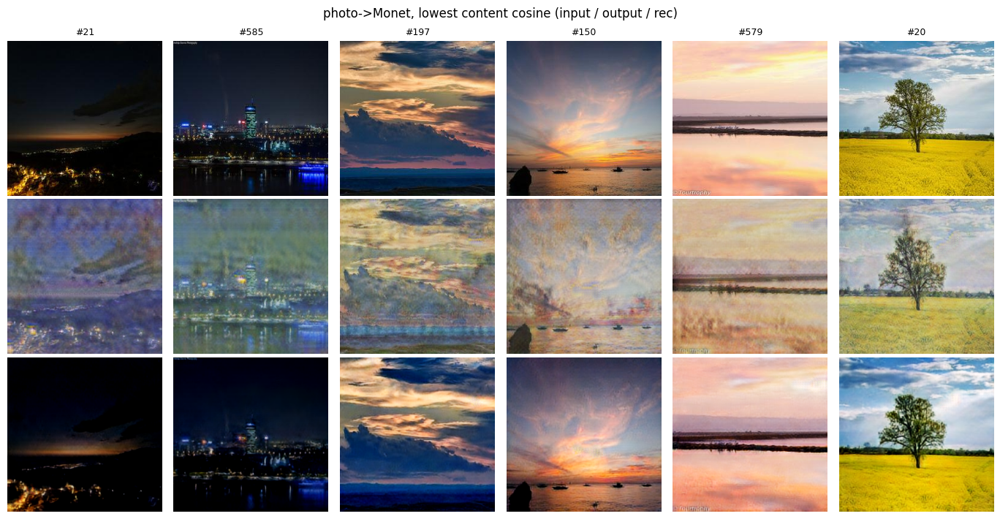

In [ ]:
worst_grid(np.argsort(cos_p2m), photo_eval, fake_monet, rec_photo,
           "photo->Monet, lowest content cosine (input / output / rec)", FIG_DIR / "worst_content_p2m.png")

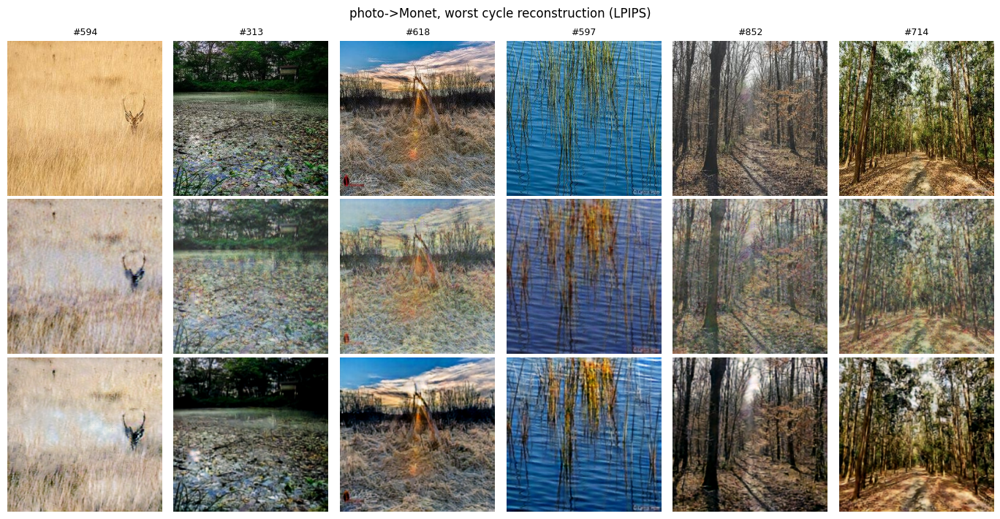

In [ ]:
worst_grid(np.argsort(-lp_recP), photo_eval, fake_monet, rec_photo,
           "photo->Monet, worst cycle reconstruction (LPIPS)", FIG_DIR / "worst_cycle_p2m.png")

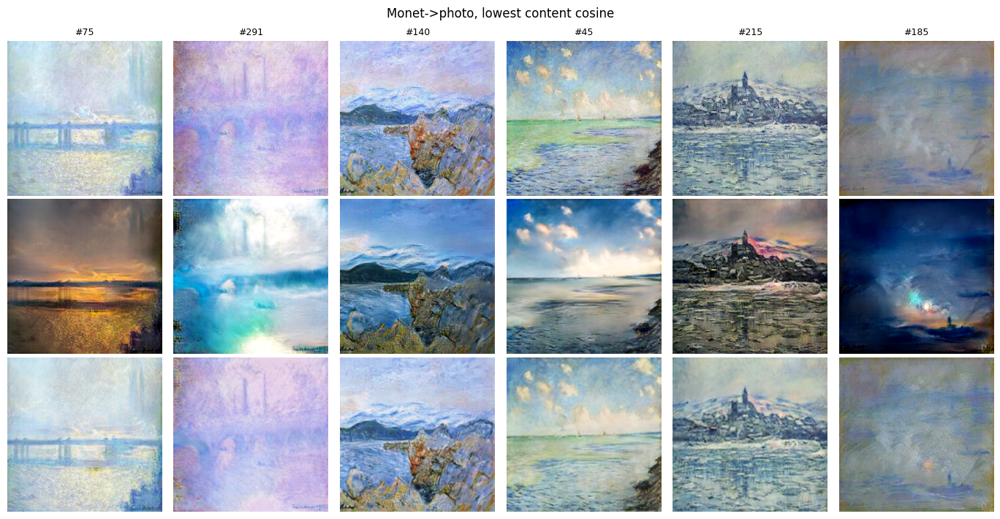

In [ ]:
worst_grid(np.argsort(cos_m2p), monet_u8, fake_photo, rec_monet,
           "Monet->photo, lowest content cosine", FIG_DIR / "worst_content_m2p.png")

In [ ]:
# does failure depend on the input? (brightness / colourfulness)
bright = photo_eval.float().mean(dim=(1, 2, 3)).numpy()
colorf = photo_eval.float().std(dim=1).mean(dim=(1, 2)).numpy()
log(f"corr(content cos, brightness) {np.corrcoef(cos_p2m, bright)[0, 1]:+.3f} | "
    f"corr(content cos, colourfulness) {np.corrcoef(cos_p2m, colorf)[0, 1]:+.3f} | "
    f"corr(rec LPIPS, brightness) {np.corrcoef(lp_recP, bright)[0, 1]:+.3f}")

[2026-10-02 01:01:14] corr(content cos, brightness) +0.142 | corr(content cos, colourfulness) -0.020 | corr(rec LPIPS, brightness) -0.133


## 13. Efficiency

In [ ]:
@torch.no_grad()
def bench_inference(G, bs=16, warmup=10, iters=50, repeats=5):
    x = torch.randn(bs, 3, CFG["img_size"], CFG["img_size"], device=DEVICE)
    if CFG["channels_last"]:
        x = x.contiguous(memory_format=torch.channels_last)
    G.eval()
    for _ in range(warmup):
        with torch.autocast(**AMP):
            G(x)
    rates = []
    for _ in range(repeats):
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        t = time.perf_counter()
        for _ in range(iters):
            with torch.autocast(**AMP):
                G(x)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        rates.append(bs * iters / (time.perf_counter() - t))
    return float(np.median(rates)), float(np.std(rates))

In [ ]:
if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
INF_IPS, INF_IPS_STD = bench_inference(EMA_P2M, iters=5 if QUICK else 50)
PEAK_INF_MEM_GB = torch.cuda.max_memory_allocated() / 1024**3 if DEVICE.type == "cuda" else float("nan")

In [ ]:
EFF = dict(
    params_G_each_M=PARAMS["G_P2M"] / 1e6,
    params_D_each_M=PARAMS["D_M"] / 1e6,
    params_total_M=PARAMS["total"] / 1e6,
    train_time_h=STATE["train_time"] / 3600,
    train_steps=STATE["step"],
    train_steps_per_s=STATE["step"] / STATE["train_time"],
    train_img_per_s_per_domain=STATE["step"] * CFG["batch_size"] / STATE["train_time"],
    infer_img_per_s_median=INF_IPS,
    infer_img_per_s_std=INF_IPS_STD,
    peak_mem_train_GB=PEAK_TRAIN_MEM_GB,
    peak_mem_infer_GB=PEAK_INF_MEM_GB,
    gpu=torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "cpu",
)
log("efficiency:", json.dumps(EFF, default=str))
pd.Series(EFF).to_frame("value")

[2026-10-02 01:01:29] efficiency: {"params_G_each_M": 11.378179, "params_D_each_M": 5.529474, "params_total_M": 33.815306, "train_time_h": 3.203462434278594, "train_steps": 64000, "train_steps_per_s": 5.549550882054048, "train_img_per_s_per_domain": 22.19820352821619, "infer_img_per_s_median": 505.3437502240652, "infer_img_per_s_std": 19.280714204249353, "peak_mem_train_GB": 6.333517074584961, "peak_mem_infer_GB": 2.9906692504882812, "gpu": "NVIDIA GeForce RTX 4090"}


,value
params_G_each_M,11.378179
params_D_each_M,5.529474
params_total_M,33.815306
train_time_h,3.203462
train_steps,64000
train_steps_per_s,5.549551
train_img_per_s_per_domain,22.198204
infer_img_per_s_median,505.34375
infer_img_per_s_std,19.280714
peak_mem_train_GB,6.333517


## 14. Export predictions
Both directions as 256x256 RGB jpgs, named after their input file, in the folder layout the course
script expects. Everything in these folders is a generator output, plus the global colour
correction if it was selected above (honor code: no training image is copied or edited).

In [ ]:
PRED_A2B = OUT_DIR / "pred_A2B"   # Monet -> photo (generated photos)
PRED_B2A = OUT_DIR / "pred_B2A"   # photo -> Monet (generated Monets)

def export_folder(fn, imgs_u8, files, out_dir, bs=256):
    out_dir.mkdir(parents=True, exist_ok=True)
    for i in range(0, len(imgs_u8), bs):
        out = fn(imgs_u8[i:i + bs])
        for j, im in enumerate(out):
            Image.fromarray(im.permute(1, 2, 0).numpy()).save(
                out_dir / f"{files[i + j].stem}.jpg", format="JPEG", quality=95)

In [ ]:
t0 = time.time()
export_folder(to_photo, monet_u8, monet_files, PRED_A2B)
export_folder(to_monet, photo_u8, photo_files, PRED_B2A)
n_a2b = len(list(PRED_A2B.glob("*.jpg")))
n_b2a = len(list(PRED_B2A.glob("*.jpg")))
assert n_a2b == len(monet_files) and n_b2a == len(photo_files)
assert len(set(VAL_IN_IDX.tolist()) & official_idx) == 0   # selection never saw the scored photos
log(f"pred_A2B {n_a2b} files | pred_B2A {n_b2a} files | {time.time() - t0:.0f}s")

[2026-10-02 01:02:23] pred_A2B 300 files | pred_B2A 7038 files | 49s


## 15. Official score
The course script's computation, run on the exported folders: first 300 files by name in each
folder, both directions, averaged. Running `Part3_Evaluation_Script.ipynb` itself on these folders
should give the same numbers (up to tiny GPU-level differences).

In [ ]:
def first_n_images(folder, n=N_OFFICIAL):
    return sorted(p for p in Path(folder).iterdir() if p.suffix.lower() in IMG_EXT)[:n]

off_real_m = tv_feats(pils_from_files(first_n_images(MONET_DIR)))
off_real_p = tv_feats(pils_from_files(first_n_images(PHOTO_DIR)))
off_gen_m = tv_feats(pils_from_files(first_n_images(PRED_B2A)))
off_gen_p = tv_feats(pils_from_files(first_n_images(PRED_A2B)))

In [ ]:
OFF = official_score(off_real_m, off_gen_m, off_real_p, off_gen_p)
M.update({f"official_{k}": float(v) for k, v in OFF.items()})
log(f"[Photo->Monet] FID={OFF['fid_b2a']:.3f}  MiFID={OFF['mifid_b2a']:.4f}")
log(f"[Monet->Photo] FID={OFF['fid_a2b']:.3f}  MiFID={OFF['mifid_a2b']:.4f}")
log(f"submission: FID={OFF['FID']:.4f}  MiFID={OFF['MiFID']:.4f}  -> score {OFF['score']:.4f}")

[2026-10-02 01:03:13] [Photo->Monet] FID=100.538  MiFID=0.4099
[2026-10-02 01:03:13] [Monet->Photo] FID=99.576  MiFID=0.4170
[2026-10-02 01:03:13] submission: FID=100.0568  MiFID=0.4135  -> score 50.2351


In [ ]:
SUB_CSV = OUT_DIR / "submission.csv"
pd.DataFrame([{"ID": 1, "FID": OFF["FID"], "MiFID": OFF["MiFID"]}]).to_csv(SUB_CSV, index=False)
log(f"wrote {SUB_CSV}")
print(open(SUB_CSV).read())

[2026-10-02 01:03:13] wrote /app/content/data266_cyclegan_v3/submission.csv
ID,FID,MiFID
1,100.05676111548,0.41345334997946315



## 16. Blinded human audit (30 fixed samples, 2 raters)

- 30 samples fixed by SEED: 20 photo→Monet (held-out photos) + 10 Monet→photo
- each one is a side-by-side `input | output`, renamed to an anonymous id and shuffled, so raters don't see file names, direction or epoch. Mapping is in `_key.csv` (raters don't open it)
- each rater fills their own csv independently, no discussing
- 1-5 scores:
  - **style**: does the output look like the target domain? 1 = no, 5 = can't tell it apart
  - **content**: is the input's scene/layout kept? 1 = unrecognisable, 5 = fully kept
  - **artifacts**: 1 = severe (checkerboard, blotches, colour bleeding), 5 = none

In [ ]:
AUDIT_DIR = OUT_DIR / "human_audit"
(AUDIT_DIR / "images").mkdir(parents=True, exist_ok=True)

ars = np.random.RandomState(SEED + 266)
a_p = ars.choice(len(photo_eval), 20, replace=False)
a_m = ars.choice(len(monet_u8), 10, replace=False)
items = ([("photo2monet", int(i), photo_eval[i], fake_monet[i]) for i in a_p]
         + [("monet2photo", int(i), monet_u8[i], fake_photo[i]) for i in a_m])
order = ars.permutation(len(items))

In [ ]:
key_rows = []
for k, oi in enumerate(order):
    sid = f"S{k + 1:02d}"
    direction, idx, inp, out = items[oi]
    gap = torch.full((3, inp.shape[1], 8), 255, dtype=torch.uint8)
    pair = torch.cat([inp, gap, out], dim=2)
    Image.fromarray(pair.permute(1, 2, 0).numpy()).save(AUDIT_DIR / "images" / f"{sid}.png")
    key_rows.append(dict(sample_id=sid, direction=direction, index=idx))
pd.DataFrame(key_rows).to_csv(AUDIT_DIR / "_key.csv", index=False)

In [ ]:
for r in ("rater1", "rater2"):
    p = AUDIT_DIR / f"{r}.csv"
    if not p.exists():   # don't overwrite filled sheets
        pd.DataFrame(dict(sample_id=[f"S{k + 1:02d}" for k in range(30)],
                          style="", content="", artifacts="", notes="")).to_csv(p, index=False)

html = ["<html><body style='font-family:sans-serif'>",
        "<h2>Rate each pair (input | output) 1-5 on style, content, artifacts</h2>"]
for k in range(30):
    html.append(f"<div style='margin:12px 0'><b>S{k + 1:02d}</b><br>"
                f"<img src='images/S{k + 1:02d}.png' width='520'></div>")
html.append("</body></html>")
(AUDIT_DIR / "audit_sheet.html").write_text("\n".join(html))
log(f"audit packet in {AUDIT_DIR}")

[2026-10-02 01:03:48] audit packet in /app/content/data266_cyclegan_v3/human_audit


Run this once both raters have filled `rater1.csv` and `rater2.csv`. Skips if they're still empty.

In [ ]:
def cohen_kappa_score(a, b, weights=None, labels=(1, 2, 3, 4, 5)):
    # same as sklearn's, without the dependency. fixed 1-5 scale.
    k = len(labels)
    pos = {lab: i for i, lab in enumerate(labels)}
    O = np.zeros((k, k))
    for x, y in zip(a, b):
        O[pos[x], pos[y]] += 1
    O /= O.sum()
    E = np.outer(O.sum(1), O.sum(0))
    i, j = np.indices((k, k))
    if weights == "quadratic":
        W = (i - j) ** 2 / (k - 1) ** 2
    elif weights == "linear":
        W = np.abs(i - j) / (k - 1)
    else:
        W = (i != j).astype(float)
    denom = (W * E).sum()
    return float("nan") if denom == 0 else float(1 - (W * O).sum() / denom)


AUDIT = {}
CRIT = ["style", "content", "artifacts"]
r1 = pd.read_csv(AUDIT_DIR / "rater1.csv")
r2 = pd.read_csv(AUDIT_DIR / "rater2.csv")
filled = all(pd.to_numeric(r[c], errors="coerce").notna().all() for r in (r1, r2) for c in CRIT)
print("ratings complete:", filled)

ratings complete: False


In [ ]:
if filled:
    rows = []
    for c in CRIT:
        a, b = r1[c].astype(int).values, r2[c].astype(int).values
        assert set(a) | set(b) <= {1, 2, 3, 4, 5}, f"{c}: scores must be 1-5"
        rows.append(dict(criterion=c, mean_r1=a.mean(), mean_r2=b.mean(), mean_both=(a.mean() + b.mean()) / 2,
                         exact_agree=(a == b).mean(), within1_agree=(np.abs(a - b) <= 1).mean(),
                         kappa=cohen_kappa_score(a, b),
                         kappa_quadratic=cohen_kappa_score(a, b, weights="quadratic")))
    AUDIT_TABLE = pd.DataFrame(rows).round(3)
    display(AUDIT_TABLE)
else:
    log("audit: rating sheets not complete yet")

[2026-10-02 01:03:50] audit: rating sheets not complete yet


In [ ]:
if filled:
    key = pd.read_csv(AUDIT_DIR / "_key.csv")
    both = r1[CRIT].astype(int).add(r2[CRIT].astype(int)).div(2)
    both = both.assign(sample_id=r1.sample_id).merge(key, on="sample_id")
    BY_DIR = both.groupby("direction")[CRIT].mean().round(2)
    AUDIT = dict(overall_mean=float(both[CRIT].values.mean()),
                 table=AUDIT_TABLE.to_dict("records"), by_direction=BY_DIR.to_dict())
    log("audit:\n" + AUDIT_TABLE.to_string(index=False) + "\nby direction:\n" + BY_DIR.to_string())
    display(BY_DIR)

## 17. METRICS.md
Fill in the Kaggle numbers from the leaderboard after submitting, then run.

In [ ]:
KAGGLE_PUBLIC = None    # leaderboard score after uploading submission.csv
KAGGLE_PRIVATE = None
KAGGLE_RANK = None      # e.g. "7 / 41"

def fmt(v, p=4):
    if v is None or (isinstance(v, float) and math.isnan(v)):
        return "-"
    return f"{v:.{p}f}" if isinstance(v, float) else str(v)

In [ ]:
L = ["# METRICS: CycleGAN Monet <-> Photo", "",
     f"SID4={SID4:04d} | SEED={SEED} | SLICE={SLICE} | HP_ID={HP_ID} | CLS_A={CLS_A} | CLS_B={CLS_B}",
     f"Best EMA checkpoint: epoch {best['epoch']} of {CFG['epochs']} | GPU: {EFF['gpu']}",
     f"Final config: `{FINAL_CONFIG}` {CANDIDATES[FINAL_CONFIG]} | colour calibration: {sorted(CAL) or 'none'}", "",
     "## Distribution / translation metrics (Inception-v3 pool3, 2048-d)", "",
     "| Metric | Photo -> Monet | Monet -> Photo |",
     "|---|---|---|",
     f"| FID (lower better) | {fmt(M['FID_photo2monet'], 2)} | {fmt(M['FID_monet2photo'], 2)} |",
     f"| KID x1e3 (mean +- std) | {M['KID_photo2monet']*1e3:.2f} +- {M['KID_photo2monet_std']*1e3:.2f} "
     f"| {M['KID_monet2photo']*1e3:.2f} +- {M['KID_monet2photo_std']*1e3:.2f} |",
     f"| Precision | {fmt(M['precision_photo2monet'])} | {fmt(M['precision_monet2photo'])} |",
     f"| Recall | {fmt(M['recall_photo2monet'])} | {fmt(M['recall_monet2photo'])} |",
     f"| Density | {fmt(M['density_photo2monet'])} | {fmt(M['density_monet2photo'])} |",
     f"| Coverage | {fmt(M['coverage_photo2monet'])} | {fmt(M['coverage_monet2photo'])} |",
     f"| Content cosine (input vs translation) | {fmt(M['content_cos_photo2monet'])} | {fmt(M['content_cos_monet2photo'])} |",
     f"| LPIPS input vs translation | {fmt(M['LPIPS_input_vs_translation_photo2monet'])} "
     f"| {fmt(M['LPIPS_input_vs_translation_monet2photo'])} |",
     f"| Cycle reconstruction L1 | {fmt(M['cycle_L1_photo'])} (photo cycle) | {fmt(M['cycle_L1_monet'])} (Monet cycle) |",
     f"| LPIPS input vs reconstruction | {fmt(M['LPIPS_input_vs_reconstruction_photo'])} "
     f"| {fmt(M['LPIPS_input_vs_reconstruction_monet'])} |",
     "",
     f"Reference points: photo-vs-photo FID floor {M['FID_floor_photo_vs_photo']:.2f}; unrelated-pair L1 "
     f"{M['cycle_L1_unrelated_baseline']:.4f}, LPIPS {M['LPIPS_unrelated_baseline']:.4f}, content cosine "
     f"{M['content_cos_unrelated_baseline']:.4f}. MiFID (original Monet-comp formula, vs training Monets) {M['MiFID_photo2monet']:.2f}, "
     f"memorisation distance {M['memorization_dist']:.4f}.", ""]

In [ ]:
L += ["## Training losses (mean over last 25% of steps)", "",
      "| Term | Value |", "|---|---|",
      f"| Discriminator total | {stab['D_last_quarter']:.4f} |",
      f"| Generator adversarial (both) | {stab['G_adv_last_quarter']:.4f} |",
      f"| Cycle L1 (both, unweighted) | {stab['cyc_last_quarter']:.4f} (first 25%: {stab['cyc_first_quarter']:.4f}) |",
      f"| Identity L1 (both, unweighted) | {stab['idt_last_quarter']:.4f} |",
      f"| lambda_cyc / lambda_id | {CFG['lambda_cyc']} / {CFG['lambda_id']} |",
      "", "Curves: `figures/loss_curves.png`, `figures/stability_curves.png`", "",
      "## Stability", "",
      "| Metric | G | D |", "|---|---|---|",
      f"| Grad-norm median | {stab['gnG_median']:.3f} | {stab['gnD_median']:.3f} |",
      f"| Grad-norm p99 | {stab['gnG_p99']:.3f} | {stab['gnD_p99']:.3f} |",
      f"| Grad-norm max | {stab['gnG_max']:.3f} | {stab['gnD_max']:.3f} |",
      f"| NaN/Inf steps | {STATE['nan_steps']} (of {STATE['step']}) | |", ""]

In [ ]:
L += ["## Human audit (30 samples, 2 raters, 1-5)", ""]
if AUDIT:
    L += ["| Criterion | Mean | Exact agree | +-1 agree | Cohen kappa | Quadratic kappa |",
          "|---|---|---|---|---|---|"]
    for r in AUDIT["table"]:
        L.append(f"| {r['criterion']} | {r['mean_both']:.2f} | {r['exact_agree']:.0%} | {r['within1_agree']:.0%} "
                 f"| {r['kappa']:.3f} | {r['kappa_quadratic']:.3f} |")
    L += ["", f"Overall mean score: {AUDIT['overall_mean']:.2f}"]
else:
    L.append("_Pending, run the audit cells after both raters finish._")
L.append("")

In [ ]:
L += ["## Efficiency", "", "| Metric | Value |", "|---|---|",
      f"| Params per G / D | {EFF['params_G_each_M']:.2f}M / {EFF['params_D_each_M']:.2f}M |",
      f"| Params total | {EFF['params_total_M']:.2f}M |",
      f"| Training time | {EFF['train_time_h']:.2f} h ({EFF['train_steps']} steps, batch {CFG['batch_size']}) |",
      f"| Training throughput | {EFF['train_img_per_s_per_domain']:.1f} img/s per domain |",
      f"| Inference (bs 16, median of 5) | {EFF['infer_img_per_s_median']:.1f} +- {EFF['infer_img_per_s_std']:.1f} img/s |",
      f"| Peak GPU mem train / infer | {fmt(EFF['peak_mem_train_GB'], 2)} GB / {fmt(EFF['peak_mem_infer_GB'], 2)} GB |",
      "", "## Official score (course evaluation script, first 300 by name, both directions)", "",
      "| Direction | FID | MiFID |", "|---|---|---|",
      f"| Photo -> Monet (B2A) | {OFF['fid_b2a']:.3f} | {OFF['mifid_b2a']:.4f} |",
      f"| Monet -> Photo (A2B) | {OFF['fid_a2b']:.3f} | {OFF['mifid_a2b']:.4f} |",
      f"| Submitted (average) | {OFF['FID']:.4f} | {OFF['MiFID']:.4f} |",
      "", f"Score = (FID + MiFID) / 2 = {OFF['score']:.4f}. Checkpoint chosen on a separate validation set "
      f"(not the 300 scored photos); selected: {best['epoch']}.",
      "", "Submitted file: `submission.csv` (`ID,FID,MiFID`)."]

In [ ]:
(OUT_DIR / "METRICS.md").write_text("\n".join(L))
with open(OUT_DIR / "metrics.json", "w") as f:
    json.dump(dict(metrics=M, stability=stab, efficiency=EFF,
                   checks={k: bool(v) for k, v in checks.items()}, audit=AUDIT), f, indent=2, default=float)
log(f"wrote {OUT_DIR / 'METRICS.md'}")
print("\n".join(L))

[2026-10-02 01:05:29] wrote /app/content/data266_cyclegan_v3/METRICS.md
# METRICS: CycleGAN Monet <-> Photo

SID4=9002 | SEED=9002 | SLICE=2 | HP_ID=2 | CLS_A=2 | CLS_B=3
Best EMA checkpoint: epoch avg of epochs [70, 65, 60] of 80 | GPU: NVIDIA GeForce RTX 4090
Final config: `ms_id1` {'lambda_cyc': 10.0, 'lambda_id': 1.0, 'n_scales': 2} | colour calibration: ['M2P']

## Distribution / translation metrics (Inception-v3 pool3, 2048-d)

| Metric | Photo -> Monet | Monet -> Photo |
|---|---|---|
| FID (lower better) | 93.22 | 85.95 |
| KID x1e3 (mean +- std) | 20.63 +- 2.06 | 19.51 +- 2.20 |
| Precision | 0.4830 | 0.7133 |
| Recall | 0.5900 | 0.4360 |
| Density | 0.4076 | 0.7187 |
| Coverage | 0.8367 | 0.4510 |
| Content cosine (input vs translation) | 0.7343 | 0.7849 |
| LPIPS input vs translation | 0.3891 | 0.3476 |
| Cycle reconstruction L1 | 0.1168 (photo cycle) | 0.0729 (Monet cycle) |
| LPIPS input vs reconstruction | 0.2097 | 0.2871 |

Reference points: photo-vs-photo FID floor 57.3

## 18. Copy deliverables into the repo folder
Checkpoints and images.zip are too big for git, they stay in OUT_DIR.

In [ ]:
REPO_DIR = Path(os.getcwd())
if REPO_DIR.resolve() != OUT_DIR.resolve():
    for name in ["RUN_LOG.txt", "METRICS.md", "metrics.json", "config.json",
                 "train_history.csv", "eval_history.csv", "submission.csv", "screening.csv"]:
        if (OUT_DIR / name).exists():
            shutil.copy2(OUT_DIR / name, REPO_DIR / name)
    if (OUT_DIR / "figures").exists():
        shutil.copytree(OUT_DIR / "figures", REPO_DIR / "figures", dirs_exist_ok=True)
    if (RUNS_DIR / "final" / "samples").exists():
        shutil.copytree(RUNS_DIR / "final" / "samples", REPO_DIR / "samples", dirs_exist_ok=True)
    shutil.copytree(AUDIT_DIR, REPO_DIR / "human_audit", dirs_exist_ok=True)
    log(f"deliverables copied to {REPO_DIR}")
log(f"best checkpoint: {CKPT_DIR / 'best_ema.pt'} | predictions: {PRED_A2B.parent} | submission: {SUB_CSV}")

[2026-10-02 01:05:40] deliverables copied to /app
[2026-10-02 01:05:40] best checkpoint: /app/content/data266_cyclegan_v3/runs/final/checkpoints/best_ema.pt | predictions: /app/content/data266_cyclegan_v3 | submission: /app/content/data266_cyclegan_v3/submission.csv


## 19. Analysis



**Visual quality.** What carries over (brush texture, palette, soft edges) and what doesn't. Monet→photo should be the weaker direction since it has to invent detail.

**Cycle consistency.** Check table from section 9, cycle L1 vs the unrelated baseline. Note: CycleGAN can hide input info in tiny high-frequency patterns (Chu et al. 2017), so near-perfect reconstruction isn't automatically good.

**Stability / convergence.** From the curves: do D outputs stay away from 0/1, are grad norms bounded, NaN count, does the cycle loss plateau, does FID keep improving in the LR-decay phase, which epoch was best.

**Shortcomings.**
- only 300 Monets as FID reference → biased, noisy FID. KID is the better number here, and the photo-vs-photo floor gives scale
- those 300 are also the training set, so photo→Monet FID partly rewards matching training data (MiFID memorisation distance checks we're not copying)
- Inception is an ImageNet photo model, weaker judge of painting style than of photo realism
- content cosine uses the same feature space, it's semantic not pixel-level
- not bit-reproducible run to run (cudnn autotune, atomics)

**Human audit.** Means + kappa per criterion (Landis & Koch scale). Low kappa with high ±1 agreement usually means raters rank the same way but use the scale differently.


**What v3 changed and whether it helped.** Screening table (which setting won and by how much), longer training, checkpoint selection by the course metric, weight averaging, colour calibration (used or not, and its validation effect). Compare the official score with v1 (51.33).